# Lassa seroreactivity — paper figure notebook

This notebook contains only the analyses and plots needed for the current paper story.

**Core narrative**
1. Population level: identify the most prevalent seroreactive viral genuses across viral families.
2. Individual level: show how those species-level responses are distributed across Lassa fever survivors, household contacts, and US healthy controls.
3. Outcome: test whether selected viral species distinguish survivors from household contacts.
4. Sequence mechanism: use exact 8-aa sequence linkage to visualize representative cross-species peptide clusters containing *Mammarenavirus lassaense* and *Orthonairovirus haemorrhagiae*.
5. Merge ELISA data with PhIP-Seq seroreactivity data.

The standardized master peptide library is the sole peptide annotation/reference file used downstream. Original annotations are retained in that file, while standardized ICTV 2025 taxonomy and protein annotations are used for analysis and plotting.

In [80]:

# 0. IMPORTS AND CONFIGURATION


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

from collections import defaultdict
from itertools import combinations
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
from matplotlib.lines import Line2D

sns.set_context('notebook')
sns.set_style('white')

# Input files -

Z_SL_FILE = 'z_score_df_SL_over_US_090226.csv'
Z_HBDB_FILE = 'z_hbdb_loo_results_090226.csv'
RPK_SL_FILE = './preprocessing/earliest_tp_rpk_avg_value_for_cohort_techreps_071626.csv'
RPK_HBDB_FILE = './preprocessing/hbdb_pass_100k_techreps_averaged_071626.csv'
LASV_ELISA_FILE = '../LASV_ELISA_Neut_and_PhIP_Seq_result_corrected_w_month_year_filtered_first_tp.csv'
REFERENCE_PEPTIDE_FILE = 'lassa_library_sequences_species_standardized_070726_ICTV_corrected.csv'


# Analysis thresholds -

Z_THRESH = 3
SENS_MIN = 0.05
SPEC_MIN = 0.99

# Remove taxa/accessions excluded from the original downstream analysis
TAXA_TO_REMOVE = ['Trypanosomatidae', 'Konkoviridae']
ACCESSIONS_TO_REMOVE = ['WAK75154.1', 'ANT96597.1'] #accessions mapping to ampicillin resistance proteins found in vaccine constructs

# Heatmap selection
TOP_N_PER_FAMILY = 2

# Network targets
TARGET_LASSA = 'Mammarenavirus lassaense'
TARGET_HAEM = 'Orthonairovirus haemorrhagiae'

FIG_DIR = './paper_figures'

## 1. Load standardized peptide reference and z-score matrices

Only the standardized master peptide library is used to supply peptide sequence, accession, ICTV species/genus/family, and standardized protein information. The z-score files provide the participant-level seroreactivity measurements.

In [81]:

# 1. LOAD INPUTS -


import os
os.makedirs(FIG_DIR, exist_ok=True)

# Participant z-scores
df_sl_z = pd.read_csv(Z_SL_FILE).set_index('peptide')
df_hbdb_z = pd.read_csv(Z_HBDB_FILE).set_index('peptide')

# participant rpk values
df_sl_rpk = pd.read_csv(RPK_SL_FILE).set_index('peptide')
df_hbdb_rpk = pd.read_csv(RPK_HBDB_FILE).set_index('peptide')

### 2. Define the filtered high-specificity peptide set

A peptide is considered reactive when its participant-level z-score is >3. Peptides retained for the downstream viral analysis have ≥5% sensitivity in the SL cohort and ≥99% specificity in HBDB, followed by the same exclusion of non-target taxa/artificial-vector accessions used previously.

In [82]:

# 2. PEPTIDE-LEVEL FILTERING -


pass_sl = df_sl_z > Z_THRESH
pass_hbdb = df_hbdb_z > Z_THRESH

peptide_stats = pd.DataFrame({
    'sensitivity': pass_sl.mean(axis=1),
    'specificity': 1 - pass_hbdb.mean(axis=1)
})


hits = peptide_stats[
    (peptide_stats['sensitivity'] >= SENS_MIN) &
    (peptide_stats['specificity'] >= SPEC_MIN)
].copy()

hits = pd.DataFrame(hits).reset_index('peptide')

print(hits.peptide.nunique(), 'before exclusion of taxa and accessions')


1292 before exclusion of taxa and accessions


In [83]:
peps_metadata = pd.read_csv(REFERENCE_PEPTIDE_FILE)
peps_metadata.rename(columns={'seq_id':'peptide'}, inplace=True)

In [84]:
hits = hits.merge(peps_metadata, on='peptide', how='left')

In [85]:
hits.head(1)
hits.columns.to_list()

['peptide',
 'sensitivity',
 'specificity',
 'sequence',
 'accession',
 'protein_name',
 'gene',
 'segment',
 'order',
 'family',
 'subfamily',
 'genus',
 'species',
 'isolate',
 'taxonomy_lineage',
 'collection_date',
 'geo_loc_name',
 'host',
 'protein_std',
 'fragment',
 'collection_date_standardized']

In [86]:
hits.to_csv('pep_hits_090726.csv')


### from those peptide hits I want to add the ICTV recognized and standardized species name, and standardize the protein it belongs to e.g. nucleoprotein, NP, capsid --> nucleoprotein

In [87]:

# Original analysis exclusions
hits = hits[
    ~hits['family'].isin(TAXA_TO_REMOVE)
].copy()

hits = hits[
    ~hits['accession'].isin(ACCESSIONS_TO_REMOVE)
].copy()


print(f'Filtered peptide hits: {hits.peptide.nunique()}')
print(f'Unique standardized species: {hits.species.nunique()}')
print(f'Unique standardized genera: {hits.genus.nunique()}')
print(f'Unique standardized families: {hits.family.nunique()}')

Filtered peptide hits: 1274
Unique standardized species: 366
Unique standardized genera: 42
Unique standardized families: 9


In [88]:
hits['accession'].nunique()

797

In [89]:
hits.columns

Index(['peptide', 'sensitivity', 'specificity', 'sequence', 'accession',
       'protein_name', 'gene', 'segment', 'order', 'family', 'subfamily',
       'genus', 'species', 'isolate', 'taxonomy_lineage', 'collection_date',
       'geo_loc_name', 'host', 'protein_std', 'fragment',
       'collection_date_standardized'],
      dtype='object')

In [90]:
hits.to_csv('pep_hits_wo_taxa_to_remove_090726.csv')

In [91]:

# 3. LONG-FORM PARTICIPANT DATA -

df_z = pd.concat([df_sl_z, df_hbdb_z], axis=1)
df_rpk = pd.concat([df_sl_rpk, df_hbdb_rpk], axis=1)

z_long = (
    df_z.loc[hits['peptide']]
    .reset_index()
    .melt(
        id_vars='peptide',
        var_name='individual',
        value_name='z_score'
    )
)

rpk_long = (
    df_rpk.loc[hits['peptide']]
    .reset_index()
    .melt(
        id_vars='peptide', 
        var_name='individual', 
        value_name='rpk'
    )
)

long = z_long.merge(
    rpk_long, 
    on=['peptide', 'individual'], 
    how='left'
)


long = long.merge(
    hits[
        [
            'peptide', 'sequence', 'species', 'genus', 'family',
            'protein_std', 'accession'
        ]
    ].drop_duplicates('peptide'),
    on='peptide',
    how='left'
)

long['cohort'] = np.where(
    z_long['individual'].str.startswith('HBDB-'),
    'HBDB',
    'SL'
)

long['category'] = np.select(
    [
        long['individual'].str.startswith('S-'),
        long['individual'].str.startswith('C-'),
        long['individual'].str.startswith('HBDB-')
    ],
    [
        'Lassa survivor',
        'Household contact',
        'US healthy'
    ],
    default='Unknown'
)

long['reactive'] = long['z_score'] > Z_THRESH


print(long['category'].nunique())

3


In [92]:
long.to_csv('long_090726.csv', index=False)

In [93]:
long.columns.to_list()

['peptide',
 'individual',
 'z_score',
 'rpk',
 'sequence',
 'species',
 'genus',
 'family',
 'protein_std',
 'accession',
 'cohort',
 'category',
 'reactive']

# Figure 1 — Population-level viral seroreactivity

**Question:** Which viral genuses show the highest seroreactive prevalence in the exposed Sierra Leone population, and how does that compare with the US healthy reference?

For each viral family, the genus with the highest SL seroreactive prevalence is selected. The final displayed genuses are ranked by SL prevalence. This keeps the figure focused on taxonomic breadth.

In [94]:
# FIGURE 1:
# GENUS-LEVEL SEROREACTIVITY + PEPTIDE-LEVEL DEPTH
#
# Panel A = genus-level seroprevalence
# Panel B = number of reactive peptides among seropositive
#            SL individuals
#
# Genus selection:
#   one representative genus per viral family,
#   defined as the genus with the highest SL seroprevalence
#
# Ordering:
#   identical genus order in both panels
#   highest SL seroprevalence at the TOP
#
# Family:
#   shown once to the left of Panel A
#
# Peptide reactivity:
#   z-score > 3

# 0. IMPORTS -

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

genus_individual = (
    long[long['genus'].notna() & long['family'].notna()]
    .groupby(
    ['family', 'genus', 'cohort', 'individual'], 
    observed=True, )['reactive'].any().reset_index(name='genus_seroreactive')
)

# 1. calculate genus-level prevalence
genus_prevalence = (
    genus_individual
    .groupby(
        ['family', 'genus', 'cohort'], 
        observed=True
    )['genus_seroreactive'].mean()
    .reset_index(
        name='seroprevalence'
    )
    )

# 2. convert to wide format for barh one row per family x genus

genus_prevalence_wide = (
    genus_prevalence.pivot(index=['family', 'genus'], columns='cohort', values='seroprevalence')
).reset_index()

#remove columns-axis name created by pivot
genus_prevalence_wide.columns.name = None

# 3. select one representative genus per family
representative_genus = (
    genus_prevalence_wide.sort_values(['family', 'SL'], ascending=[True, False]
    ).groupby('family', observed=True).head(1).copy()
)

#4. sort values
representative_genus = (
    representative_genus.sort_values(by='SL', ascending=True)
    .reset_index(drop=True) #get rid of index
)

# 5. set genus order
genus_order = (
    representative_genus['genus'].to_list()
)

# 6. make a family lookup dictionary
family_lookup = (
    representative_genus.set_index('genus')['family'].to_dict()
)

In [95]:
# PREPARE PANEL B:
# REACTIVE PEPTIDE DEPTH
#
# Among SL individuals who are seroreactive to each
# representative genus, count the number of UNIQUE reactive
# peptides mapping to that genus.


representative_genera = set(
    genus_order
)

# 7. reactive genus peptides only
sl_genus_reactive = (
    long[
        (long['cohort'] == 'SL') &
        (long['genus'].isin(
            representative_genera
        ))
        &
        (long['reactive'])
    ]
    .copy()
)


# 8. Count UNIQUE reactive peptides per individual x genus -

genus_depth = (
    sl_genus_reactive
    .groupby(
        [
            'genus',
            'individual'
        ],
        observed=True
    )['peptide']
    .nunique()
    .reset_index(
        name='n_reactive_peptides'
    )
)


# 9. set genus order

genus_depth[
    'genus'
] = pd.Categorical(
    genus_depth['genus'], 
    categories=genus_order, 
    ordered=True
)

# 10. MEDIAN DEPTH ---

depth_medians = (
    genus_depth
    .groupby(
        'genus', #after groupby, genus becomes the index of the resulting series. so can .reindex() by genus_order
        observed=True
    )['n_reactive_peptides']
    .median()
    .reindex(
        genus_order
    )
)

# 11. Quartiles / IQR 

depth_iqrs = (
    genus_depth
    .groupby(
        'genus',  
        observed=True
    )['n_reactive_peptides']
    .agg(lambda x: x.quantile(0.75) - x.quantile(0.25))
    .reindex(
        genus_order
    )
)

In [96]:
depth_medians, depth_iqrs

(genus
 Rubivirus           1.0
 Alphavirus          1.0
 Orthoebolavirus     2.0
 Henipavirus         2.0
 Orthoflavivirus     4.0
 Orthohantavirus     9.0
 Orthonairovirus    21.0
 Mammarenavirus     21.0
 Phlebovirus        19.0
 Name: n_reactive_peptides, dtype: float64,
 genus
 Rubivirus           0.0
 Alphavirus          0.0
 Orthoebolavirus     1.0
 Henipavirus         2.0
 Orthoflavivirus     3.0
 Orthohantavirus     6.0
 Orthonairovirus    10.0
 Mammarenavirus     12.0
 Phlebovirus        10.0
 Name: n_reactive_peptides, dtype: float64)

/data1/sporak/anaconda3/envs/align3/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 64.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/data1/sporak/anaconda3/envs/align3/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 85.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/data1/sporak/anaconda3/envs/align3/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 86.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/data1/sporak/anaconda3/envs/align3/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 83.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/data1/sporak/an

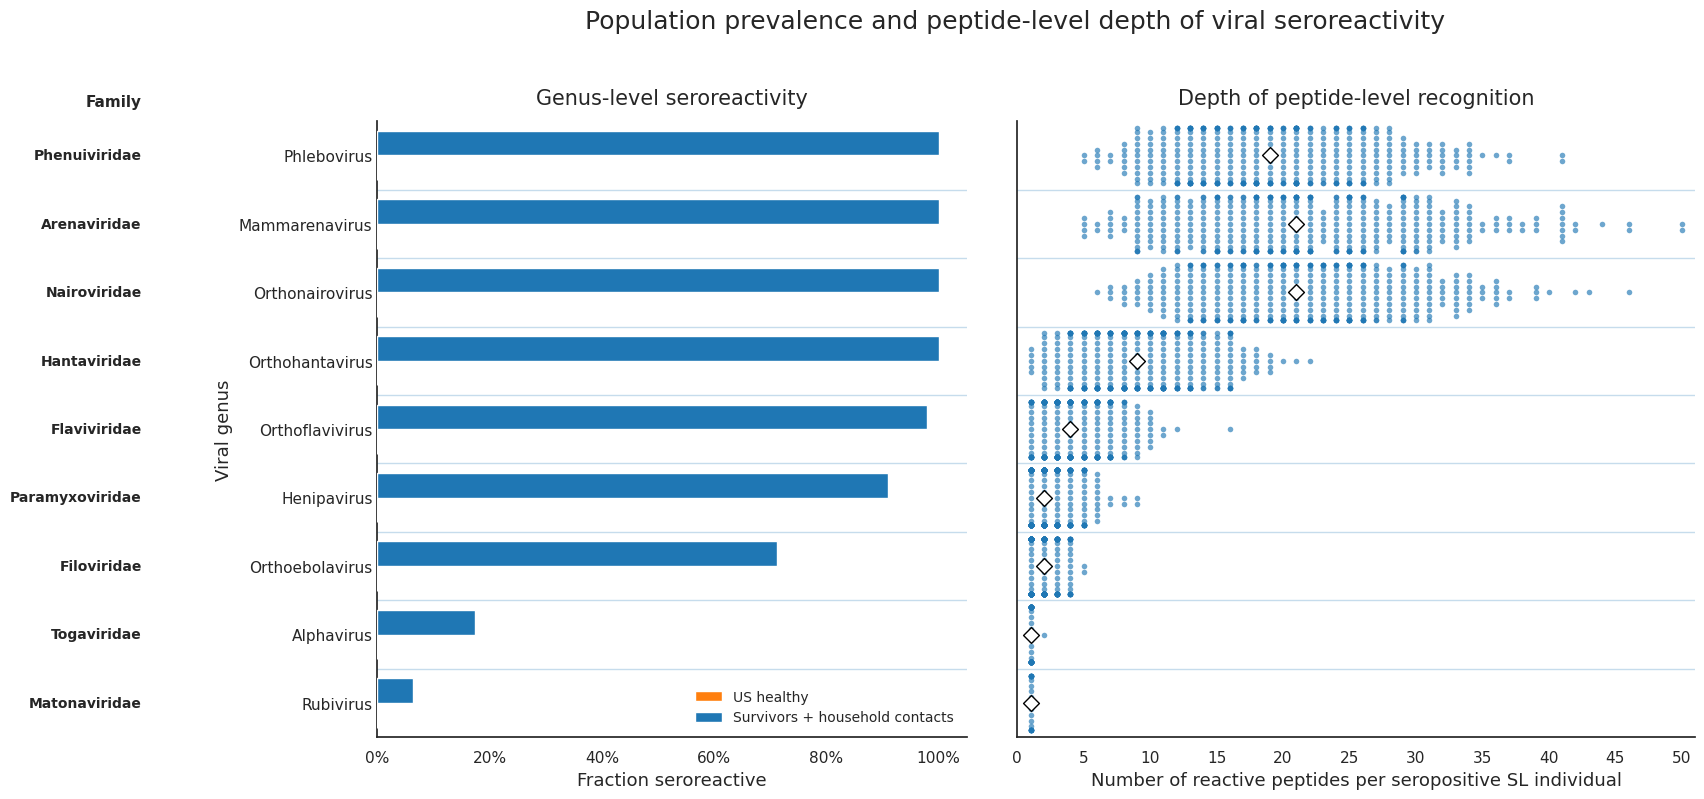

In [97]:
# 15. CREATE FIGURE
#
# sharey=True + exact same genus ordering guarantees that
# both panels occupy the same rows.


fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, 8),
    sharey=True,
    gridspec_kw={
        'width_ratios': [
            1,
            1.15
        ],
        'wspace': 0.08
    }
)


# PANEL A

ax = axes[0]

y = np.arange(len(representative_genus))

bar_height = 0.36

# US healthy

if 'HBDB' in representative_genus.columns:

    ax.barh(
        y - bar_height / 2,
        representative_genus['HBDB'],
        height=bar_height,
        label='US healthy',
        zorder=3, 
        color="tab:orange"
    )


# SL

ax.barh(
    y + bar_height / 2,
    representative_genus['SL'],
    height=bar_height,
    label='Survivors + household contacts',
    zorder=3, 
    color="tab:blue"
)


# Genus labels

ax.set_yticks(y)

ax.set_yticklabels(
    representative_genus['genus'],
    fontsize=11
)


# X-axis formatting

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f'{x:.0%}'
    )
)

ax.set_xlabel(
    'Fraction seroreactive',
    fontsize=13
)

ax.set_ylabel(
    'Viral genus',
    fontsize=13
)

ax.set_title(
    'Genus-level seroreactivity',
    fontsize=15,
    pad=12
)


# Legend

ax.legend(
    frameon=False,
    loc='lower right',
    fontsize=10
)


# FAMILY LABELS
#
# Shown ONCE, to the left of Panel A.

for i, genus in enumerate(
    genus_order
):

    family = family_lookup[
        genus
    ]

    ax.text(
        -0.40,
        i,
        family,
        transform=ax.get_yaxis_transform(),
        ha='right',
        va='center',
        fontsize=10,
        fontweight='bold',
        clip_on=False
    )


# Family heading
ax.text(
    -0.40,
    1.02,
    'Family',
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=11,
    fontweight='bold',
    clip_on=False
)


# PANEL B

ax = axes[1]


sns.swarmplot(
    data=genus_depth,
    x='n_reactive_peptides',
    y='genus',

    # EXACT SAME ORDER AS PANEL A
    order=genus_order,

    size=4,
    alpha=0.65,
    ax=ax
)


# MEDIAN DIAMONDS -


for i, genus in enumerate(
    genus_order
):

    median = depth_medians.loc[
        genus
    ]

    if pd.notna(median):

        ax.scatter(
            median,
            i,
            marker='D',
            s=65,
            facecolor='white',
            edgecolor='black',
            linewidth=1,
            zorder=10
        )



# PANEL B X-AXIS
#
# Show ticks every 5 peptides

max_depth = int(
    genus_depth[
        'n_reactive_peptides'
    ].max()
)

ax.set_xticks(
    np.arange(
        0,
        max_depth + 5,
        5
    )
)

ax.set_xlim(
    0,
    max_depth + 1
)



# LABELS -


ax.set_xlabel(
    'Number of reactive peptides per seropositive SL individual',
    fontsize=13
)

ax.set_ylabel('')

ax.set_title(
    'Depth of peptide-level recognition',
    fontsize=15,
    pad=12
)



# 16. MAKE Y-AXIS ALIGNMENT EXPLICIT

#
# Panel A and Panel B both have the same y positions because:
#
#   Panel A -> representative_genus sorted ascending SL
#   Panel B -> order=genus_order
#   sharey=True
#
# No invert_yaxis() is required.


axes[0].set_ylim(-0.5,
    len(genus_order) - 0.5
)

axes[1].set_ylim(-0.5,
    len(genus_order) - 0.5
)



# 17. OPTIONAL FAMILY SEPARATORS
#
# Family names remain only on the left, but separators help
# visually group related genera across both panels.


family_sequence = [
    family_lookup[
        genus
    ]
    for genus in genus_order
]


for i in range(
    len(family_sequence) - 1
):

    if (
        family_sequence[i]
        != family_sequence[i + 1]
    ):

        boundary = i + 0.5

        axes[0].axhline(
            boundary,
            linewidth=1,
            alpha=0.25
        )

        axes[1].axhline(
            boundary,
            linewidth=1,
            alpha=0.25
        )



# 18. CLEAN UP


for ax in axes:

    sns.despine(
        ax=ax
    )

    ax.tick_params(
        axis='y',
        length=0
    )


# 19. OVERALL TITLE


fig.suptitle(
    (
        'Population prevalence and peptide-level depth '
        'of viral seroreactivity'
    ),
    fontsize=18,
    y=1.02
)



# 20. SAVE


plt.tight_layout()

fig.savefig(
    f'{FIG_DIR}/Figure1_genus_prevalence_and_depth.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Quantify within-genus species breadth. 

**Question**: is there a difference between survivors vs household contacts vs HBDB with regards to the number of different species recognized. 

In [98]:
# get top 3 species per genus

# a species is recognized if the individual has at least 1 reactive peptide from that species
species_individual = (
    long.groupby(['individual', 'cohort', 'category', 'family', 'genus', 'species'], 
                 observed=True)['reactive']
    .any() #give boolean
    .reset_index(
        name='species_recognized'
    )
)

# collapse species -> genus 
# count how many species are recognized so n_species_recognized per individual
# we want a n_species tested per genus and a n_species_recognized_cohort and a n_species_recognized_category column

breadth_df = (
    species_individual
    .groupby(['cohort', 'category', 'individual', 'family', 'genus'], 
    observed=True)
).agg(
    n_species_tested=(
        'species', 'nunique'
    ), 
    n_species_recognized=(
        'species_recognized', 'sum'
        )
    ).reset_index()

breadth_df['fraction_species_recognized'] = (
    breadth_df['n_species_recognized'] / breadth_df['n_species_tested']
)


In [99]:
# select the top genera from plot1

breadth_top = (
    breadth_df[breadth_df['genus'].isin(representative_genera)]
)

# look at the median fraction of species recognized by cohort/category
breadth_summary = (
    breadth_top.groupby([
        'family', 'genus', 'category'
    ], observed=True
    )
    .agg(
        n_individuals=('individual', 'nunique'),
        median_fraction_species_recognized=('fraction_species_recognized', 'median'), 
        median_n_species_recognized=('n_species_recognized', 'median'),
    )
).reset_index()


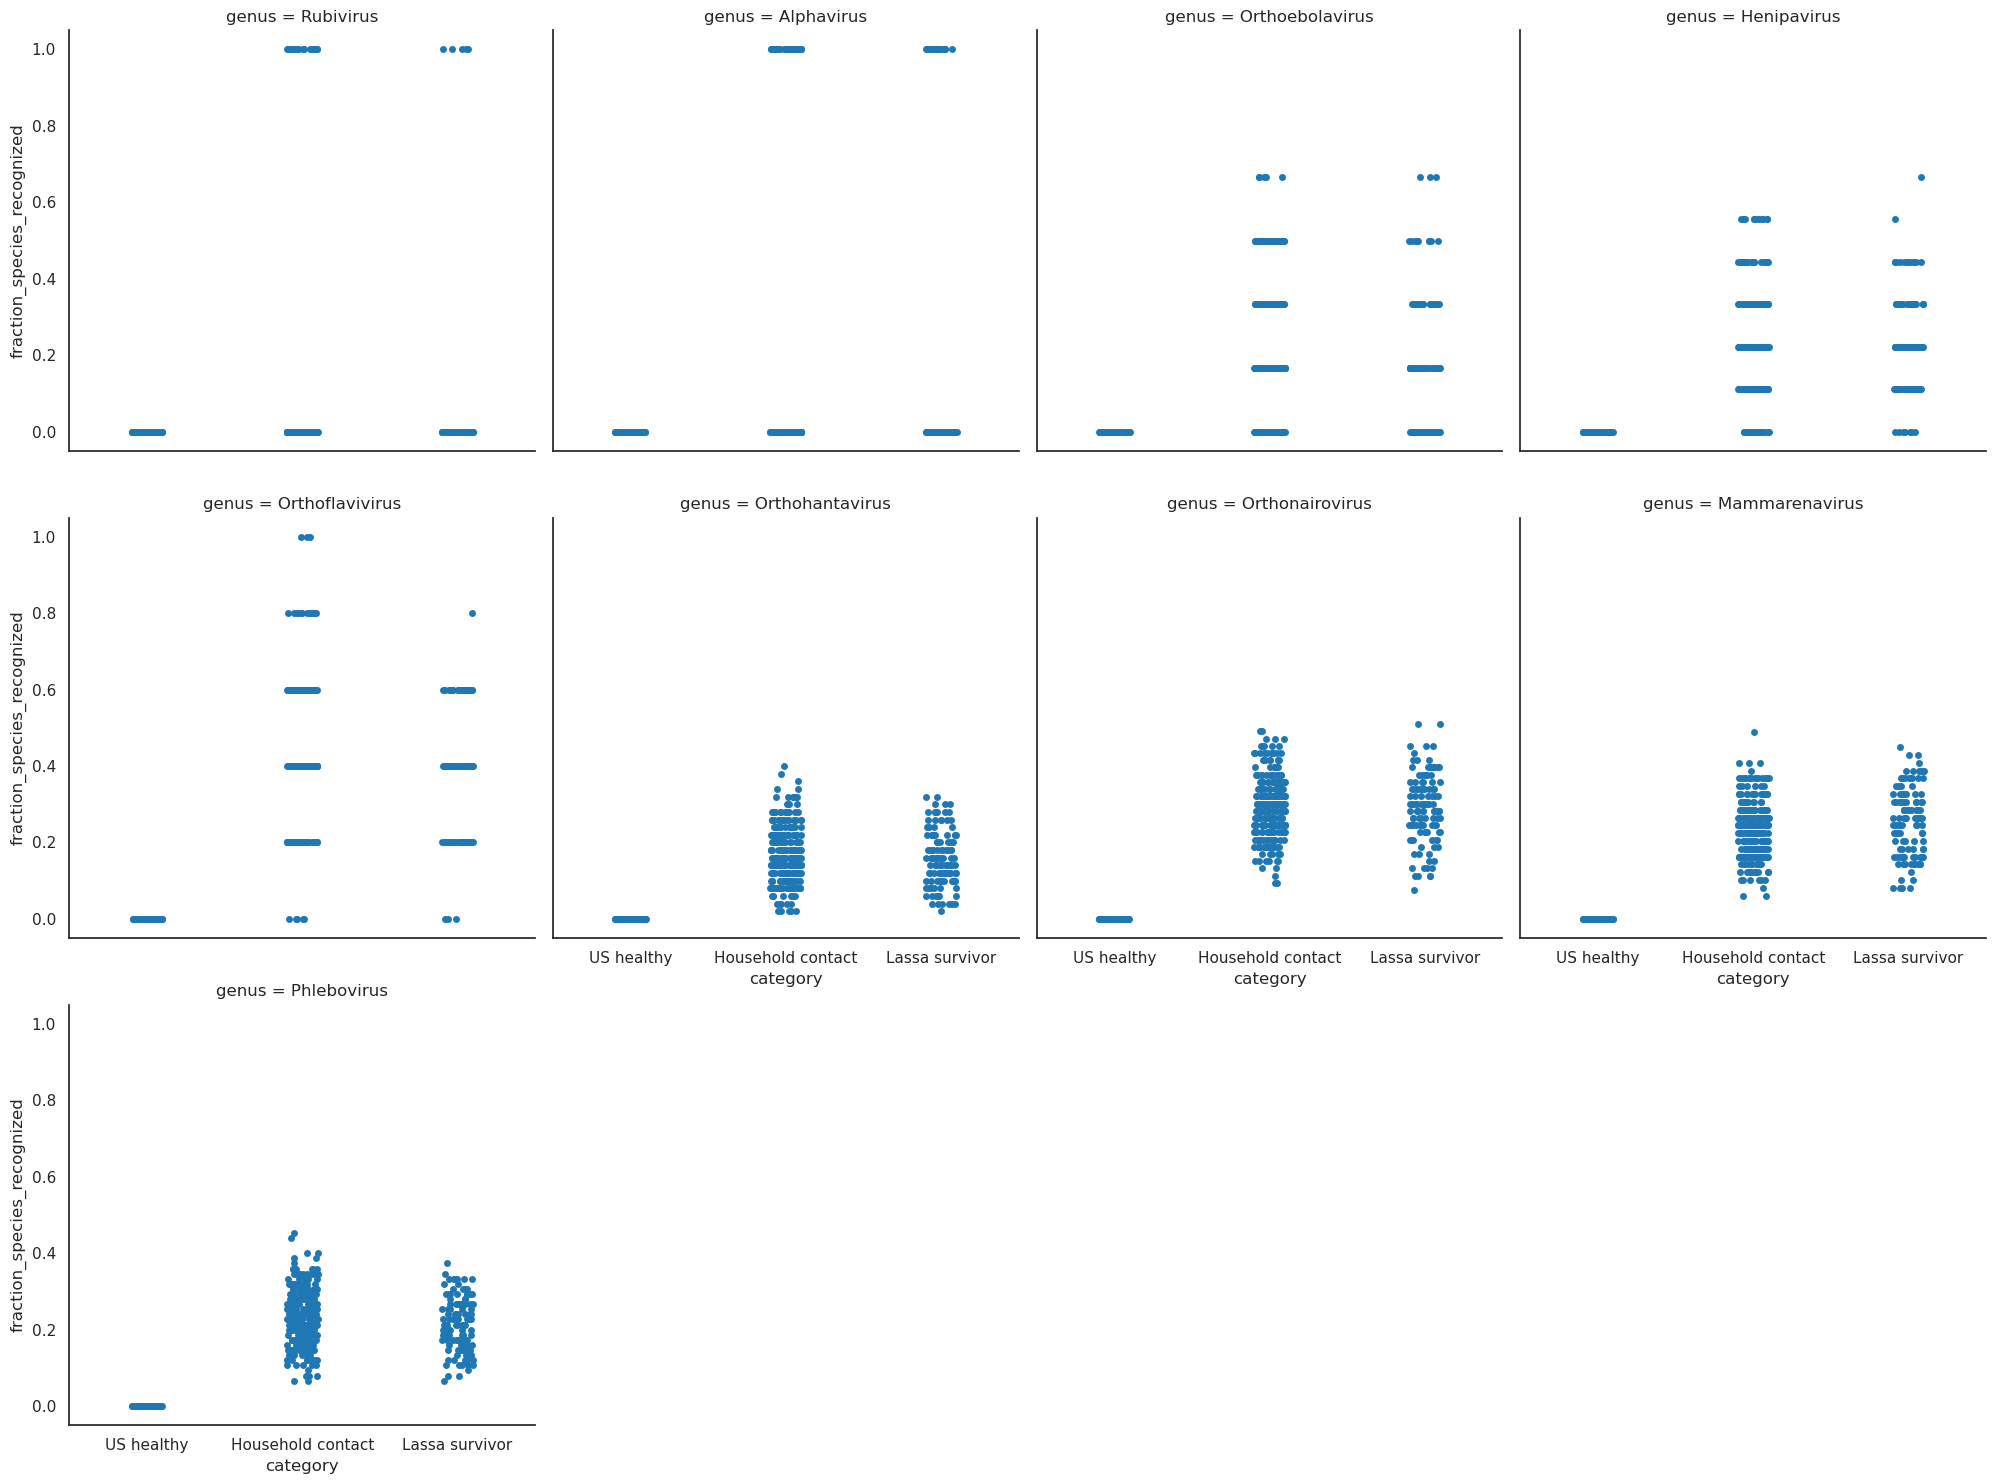

In [100]:
# plot the individual 

category_order = [
    'Lassa survivor', 'Household contact', 'US healthy'
]

g = sns.catplot(
    data = breadth_top, 
    x='category', 
    y='fraction_species_recognized', 
    col='genus', 
    col_order=genus_order, 
    col_wrap=4,
    sharey=True
)

plt.tight_layout()
plt.show()

# Figure 2 revised. Individual viral seroreactivity heatmap to LASV, DENV, EBOV, RVFV, CCHFV, WNV, MARV, YFV

In [101]:
long.loc[long['reactive'] == True, 'reactive_z'] = long['z_score'] #want to create new column reactive_z which contains z_score only when reactive ==True

In [102]:
c = long.loc[long['category'] == 'Household contact', 'individual'].drop_duplicates().to_list()
s = long.loc[long['category'] == 'Lassa survivor', 'individual'].drop_duplicates().to_list()
hbdb = long.loc[long['category'] == 'US healthy', 'individual'].drop_duplicates().to_list()

sl_individuals = c + s

ordered_individuals = (s + c + hbdb)

In [103]:
long

target = 'Mammarenavirus lassaense'

target = 'Orthoflavivirus flavi' #need to align & annotate

target = 'Orthoebolavirus zairense'

target = 'Orthomarburgvirus marburgense'

target = 'Phlebovirus riftense' #none

target = 'Orthoflavivirus nilense' #none

target = 'Orthoflavivirus denguei' #need to align & annotate -- see code downstream

target = 'Orthonairovirus haemorrhagiae'

target = 'Mammarenavirus lassaense'

target_long = (
    long[long['species'] == target]
).copy()


In [104]:
target_long['frac_reactive'] = target_long[target_long['individual'].isin(sl_individuals)].groupby('peptide', observed='True')['reactive'].mean().rename('peptide_seroprevalence')

In [105]:
target_long = target_long.reset_index()

In [106]:
peptide_order = (
    target_long[['peptide', 'protein_std', 'sequence', 'frac_reactive']].drop_duplicates('peptide').sort_values(['protein_std','frac_reactive', 'peptide'], ascending=[True, False, True])
)

ordered_peptides = (peptide_order['peptide'].to_list())

In [107]:
target_matrix = (target_long.pivot(index='peptide', columns='individual', values='reactive_z').reindex(index=ordered_peptides, columns=ordered_individuals))

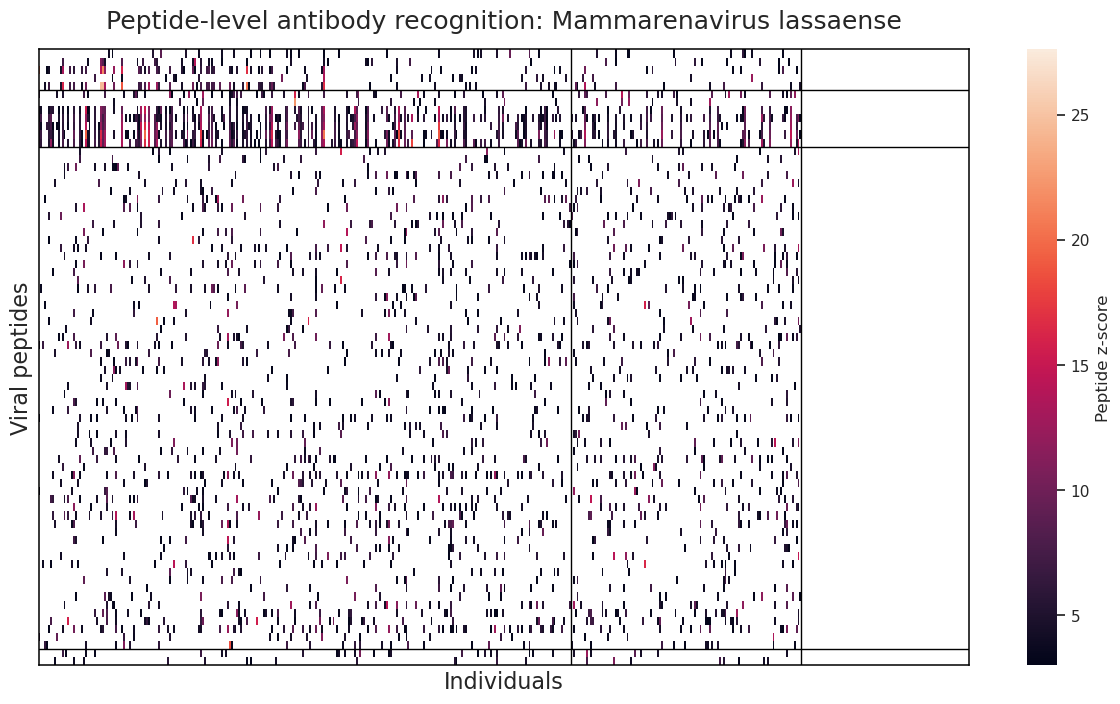

In [108]:
fig, ax = plt.subplots(figsize=(15, 8))


sns.heatmap(
    data = target_matrix, 
    yticklabels=False, 
    xticklabels=False,

    cbar_kws={'label': 'Peptide z-score'}, 
    ax=ax
)

#horizontal lines between protein groups
protein_sequence = (peptide_order['protein_std'].to_list())

for i in range(len(protein_sequence) -1):
    if protein_sequence[i] != protein_sequence[i+1]: 
        ax.axhline(y=i +1, color='black', linewidth=1, zorder=10)

#verical lines between cohort groups

n_contact = len(c)
n_survivor = len(s)

ax.axvline(x=n_contact, color='black', linewidth=1, zorder=11)

ax.axvline(x=(n_contact + n_survivor), color='black', linewidth=1, zorder=10)


ax.set_ylabel('Viral peptides', fontsize=16)
ax.set_xlabel('Individuals', fontsize=16)

ax.set_title(f'Peptide-level antibody recognition: {target}', fontsize=18, pad=15)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.1)

plt.show()

### align peptides to denguei reference sequence

In [109]:
from Bio import Entrez, SeqIO
from io import StringIO

Entrez.email = "sophie.porak@ucsf.edu"

handle = Entrez.efetch(
    db="protein",
    id="NP_056776.2",
    rettype="fasta",
    retmode="text"
)

ref_record = SeqIO.read(
    handle,
    "fasta"
)

handle.close()

denv2_ref = str(
    ref_record.seq
).upper()

print(
    ref_record.id,
    len(denv2_ref)
)

NP_056776.2 3391


In [110]:
from Bio.Align import PairwiseAligner

aligner = PairwiseAligner()

aligner.mode = 'local'

aligner.match_score = 2
aligner.mismatch_score = -1
aligner.open_gap_score = -5
aligner.extend_gap_score = -1

In [111]:
def map_peptide_to_reference(
    peptide_seq,
    reference_seq
):

    peptide_seq = str(peptide_seq).upper()
    reference_seq = str(reference_seq).upper()

    alignments = aligner.align(
        reference_seq,
        peptide_seq
    )

    if len(alignments) == 0:

        return pd.Series({
            'ref_start': np.nan,
            'ref_end': np.nan,
            'alignment_score': np.nan,
            'n_matches': np.nan,
            'identity': np.nan
        })


    # Best local alignment
    aln = alignments[0]


    # Coordinates of aligned blocks
    ref_blocks = aln.aligned[0]
    pep_blocks = aln.aligned[1]


    # Reference coordinates
    ref_start = ref_blocks[0][0] + 1
    ref_end = ref_blocks[-1][1]


    # Count aligned residues and exact matches
    n_aligned = 0
    n_matches = 0

    for (
        ref_block,
        pep_block
    ) in zip(
        ref_blocks,
        pep_blocks
    ):

        ref_s, ref_e = ref_block
        pep_s, pep_e = pep_block

        ref_piece = reference_seq[
            ref_s:ref_e
        ]

        pep_piece = peptide_seq[
            pep_s:pep_e
        ]

        n_aligned += len(
            ref_piece
        )

        n_matches += sum(
            a == b
            for a, b in zip(
                ref_piece,
                pep_piece
            )
        )


    identity = (
        n_matches
        /
        n_aligned
        if n_aligned > 0
        else np.nan
    )


    return pd.Series({
        'ref_start':
            ref_start,

        'ref_end':
            ref_end,

        'alignment_score':
            aln.score,

        'n_aligned':
            n_aligned,

        'n_matches':
            n_matches,

        'identity':
            identity
    })

In [112]:
denv_peptides = (
    long[
        long['species'] == 'Orthoflavivirus denguei'
    ][
        ['peptide', 'sequence']
    ]
    .drop_duplicates()
)

In [113]:
denv_mapping = (
    denv_peptides
    .copy()
)

denv_mapping[
    [
        'ref_start',
        'ref_end',
        'alignment_score',
        'n_aligned',
        'n_matches',
        'identity'
    ]
] = (
    denv_mapping['sequence']
    .apply(
        lambda x:
            map_peptide_to_reference(
                x,
                denv2_ref
            )
    )
)

In [114]:
display(
    denv_mapping[
        [
            'peptide',
            'ref_start',
            'ref_end',
            'n_aligned',
            'identity'
        ]
    ]
    .sort_values(
        'ref_start'
    )
)

,peptide,ref_start,ref_end,n_aligned,identity
556,WEG68698.1|polyprotein|dengue_virus_type_2|iso...,116.0,161.0,46.0,0.956522
434,UDI89630.1|polyprotein|dengue_virus_type_2|iso...,116.0,161.0,46.0,0.913043
142,AMN88556.1|polyprotein|Dengue_virus|isolate=Br...,422.0,459.0,38.0,0.500000
143,AMN88556.1|polyprotein|Dengue_virus|isolate=Br...,576.0,617.0,42.0,0.690476
144,AMN88556.1|polyprotein|Dengue_virus|isolate=Br...,604.0,641.0,38.0,0.578947
154,ANC57592.1|polyprotein|dengue_virus_type_1|iso...,629.0,661.0,33.0,0.787879
84,AFZ40120.1|polyprotein|dengue_virus_type_2|iso...,944.0,989.0,46.0,0.956522
401,QVJ82483.1|polyprotein|dengue_virus_type_4|iso...,954.0,990.0,37.0,0.756757
86,AFZ40123.1|polyprotein|dengue_virus_type_2|iso...,1013.0,1058.0,46.0,0.847826
769,XLT96517.1|polyprotein|dengue_virus_type_3|iso...,1475.0,1519.0,45.0,0.711111


In [115]:
denv_mapping[
    'identity_percent'
] = (
    denv_mapping[
        'identity'
    ]
    * 100
)

In [116]:
from Bio import Entrez, SeqIO

Entrez.email = "SOPHIE.PORAK@UCSF.EDU"

handle = Entrez.efetch(
    db='protein',
    id='NP_056776.2',
    rettype='gb',
    retmode='text'
)

ref_gb = SeqIO.read(
    handle,
    'genbank'
)

handle.close()

In [117]:
for feature in ref_gb.features:

    if feature.type in [
        'mat_peptide',
        'Region'
    ]:

        print(
            feature.type,
            feature.location,
            feature.qualifiers
        )

mat_peptide [0:114] {'product': ['anchored capsid protein ancC'], 'protein_id': ['NP_739581.2'], 'db_xref': ['VBRC:35917'], 'calculated_mol_wt': ['13167']}
mat_peptide [0:100] {'product': ['capsid protein C'], 'protein_id': ['NP_739591.2'], 'db_xref': ['VBRC:35918'], 'calculated_mol_wt': ['11737']}
Region [4:114] {'region_name': ['Flavi_capsid'], 'note': ['Flavivirus capsid protein C; pfam01003'], 'db_xref': ['CDD:366413']}
mat_peptide [114:280] {'product': ['membrane glycoprotein precursor prM'], 'protein_id': ['NP_739582.2'], 'db_xref': ['VBRC:35919'], 'calculated_mol_wt': ['18929']}
mat_peptide [114:205] {'product': ['protein pr'], 'name': ['peptide pr'], 'protein_id': ['YP_009164954.1'], 'calculated_mol_wt': ['10534']}
Region [119:198] {'region_name': ['Flavi_propep'], 'note': ['Flavivirus polyprotein propeptide; pfam01570'], 'db_xref': ['CDD:366710']}
mat_peptide [205:280] {'product': ['membrane glycoprotein M'], 'protein_id': ['NP_739592.2'], 'db_xref': ['VBRC:35920'], 'calculate

In [118]:

# DENV-2 MATURE PROTEIN BOUNDARIES

protein_boundaries = []

for feature in ref_gb.features:

    if feature.type == 'mat_peptide':

        product = feature.qualifiers.get(
            'product',
            ['unknown']
        )[0]

        start = int(
            feature.location.start
        ) + 1

        end = int(
            feature.location.end
        )

        protein_boundaries.append({
            'protein': product,
            'ref_start': start,
            'ref_end': end
        })


protein_boundaries = pd.DataFrame(
    protein_boundaries
)

display(
    protein_boundaries
)

,protein,ref_start,ref_end
0,anchored capsid protein ancC,1,114
1,capsid protein C,1,100
2,membrane glycoprotein precursor prM,115,280
3,protein pr,115,205
4,membrane glycoprotein M,206,280
5,envelope protein E,281,775
6,nonstructural protein NS1,776,1127
7,nonstructural protein NS2A,1128,1345
8,nonstructural protein NS2B,1346,1475
9,nonstructural protein NS3,1476,2093


In [119]:
# ASSIGN MATURE DENV PROTEIN


def assign_mature_protein(
    peptide_start,
    peptide_end,
    boundaries
):

    if (
        pd.isna(peptide_start)
        or
        pd.isna(peptide_end)
    ):
        return pd.Series({
            'mature_protein': np.nan,
            'protein_start': np.nan,
            'protein_end': np.nan,
            'overlap_fraction': np.nan
        })


    peptide_len = (
        peptide_end
        - peptide_start
        + 1
    )


    best = None
    best_overlap = 0


    for _, row in boundaries.iterrows():

        overlap_start = max(
            peptide_start,
            row['ref_start']
        )

        overlap_end = min(
            peptide_end,
            row['ref_end']
        )


        if overlap_start <= overlap_end:

            overlap = (
                overlap_end
                - overlap_start
                + 1
            )

            if overlap > best_overlap:

                best_overlap = overlap

                best = {
                    'mature_protein':
                        row['protein'],

                    'protein_start':
                        max(
                            1,
                            peptide_start
                            - row['ref_start']
                            + 1
                        ),

                    'protein_end':
                        peptide_end
                        - row['ref_start']
                        + 1,

                    'overlap_fraction':
                        overlap
                        / peptide_len
                }


    if best is None:

        return pd.Series({
            'mature_protein': np.nan,
            'protein_start': np.nan,
            'protein_end': np.nan,
            'overlap_fraction': np.nan
        })


    return pd.Series(best)

In [120]:
protein_assignment = (
    denv_mapping[
        [
            'ref_start',
            'ref_end'
        ]
    ]
    .apply(
        lambda row:
            assign_mature_protein(
                row['ref_start'],
                row['ref_end'],
                protein_boundaries
            ),
        axis=1
    )
)

In [121]:
denv_mapping = pd.concat(
    [
        denv_mapping,
        protein_assignment
    ],
    axis=1
)

In [122]:
display(
    denv_mapping[
        [
            'peptide',
            'ref_start',
            'ref_end',
            'mature_protein',
            'protein_start',
            'protein_end',
            'overlap_fraction',
            'identity'
        ]
    ]
)

,peptide,ref_start,ref_end,mature_protein,protein_start,protein_end,overlap_fraction,identity
84,AFZ40120.1|polyprotein|dengue_virus_type_2|iso...,944.0,989.0,nonstructural protein NS1,169.0,214.0,1.000000,0.956522
85,AFZ40123.1|polyprotein|dengue_virus_type_2|iso...,3346.0,3391.0,RNA-dependent RNA polymerase NS5,855.0,900.0,1.000000,0.804348
86,AFZ40123.1|polyprotein|dengue_virus_type_2|iso...,1013.0,1058.0,nonstructural protein NS1,238.0,283.0,1.000000,0.847826
87,AFZ40123.1|polyprotein|dengue_virus_type_2|iso...,1611.0,1656.0,nonstructural protein NS3,136.0,181.0,1.000000,0.913043
141,AMN88556.1|polyprotein|Dengue_virus|isolate=Br...,3105.0,3150.0,RNA-dependent RNA polymerase NS5,614.0,659.0,1.000000,0.565217
142,AMN88556.1|polyprotein|Dengue_virus|isolate=Br...,422.0,459.0,envelope protein E,142.0,179.0,1.000000,0.500000
143,AMN88556.1|polyprotein|Dengue_virus|isolate=Br...,576.0,617.0,envelope protein E,296.0,337.0,1.000000,0.690476
144,AMN88556.1|polyprotein|Dengue_virus|isolate=Br...,604.0,641.0,envelope protein E,324.0,361.0,1.000000,0.578947
145,AMN88556.1|polyprotein|Dengue_virus|isolate=Br...,1611.0,1655.0,nonstructural protein NS3,136.0,180.0,1.000000,0.733333
146,AMN88556.1|polyprotein|Dengue_virus|isolate=Br...,1771.0,1816.0,nonstructural protein NS3,296.0,341.0,1.000000,0.782609


In [123]:
display(
    denv_mapping[
        [
            'peptide',
            'ref_start',
            'ref_end',
            'mature_protein',
            'protein_start',
            'protein_end',
            'identity'
        ]
    ]
)

,peptide,ref_start,ref_end,mature_protein,protein_start,protein_end,identity
84,AFZ40120.1|polyprotein|dengue_virus_type_2|iso...,944.0,989.0,nonstructural protein NS1,169.0,214.0,0.956522
85,AFZ40123.1|polyprotein|dengue_virus_type_2|iso...,3346.0,3391.0,RNA-dependent RNA polymerase NS5,855.0,900.0,0.804348
86,AFZ40123.1|polyprotein|dengue_virus_type_2|iso...,1013.0,1058.0,nonstructural protein NS1,238.0,283.0,0.847826
87,AFZ40123.1|polyprotein|dengue_virus_type_2|iso...,1611.0,1656.0,nonstructural protein NS3,136.0,181.0,0.913043
141,AMN88556.1|polyprotein|Dengue_virus|isolate=Br...,3105.0,3150.0,RNA-dependent RNA polymerase NS5,614.0,659.0,0.565217
142,AMN88556.1|polyprotein|Dengue_virus|isolate=Br...,422.0,459.0,envelope protein E,142.0,179.0,0.500000
143,AMN88556.1|polyprotein|Dengue_virus|isolate=Br...,576.0,617.0,envelope protein E,296.0,337.0,0.690476
144,AMN88556.1|polyprotein|Dengue_virus|isolate=Br...,604.0,641.0,envelope protein E,324.0,361.0,0.578947
145,AMN88556.1|polyprotein|Dengue_virus|isolate=Br...,1611.0,1655.0,nonstructural protein NS3,136.0,180.0,0.733333
146,AMN88556.1|polyprotein|Dengue_virus|isolate=Br...,1771.0,1816.0,nonstructural protein NS3,296.0,341.0,0.782609


In [124]:
target = 'Orthoflavivirus denguei' #need to align & annotate

long_denv = (
    long[long['species'] == target]
).copy()

denv_annotation = (
    denv_mapping[
        [
            'peptide',
            'ref_start',
            'ref_end',
            'mature_protein',
            'protein_start',
            'protein_end',
            'identity',
            'n_aligned'
        ]
    ]
    .drop_duplicates('peptide')
)

long_denv = (
    long_denv
    .merge(
        denv_annotation,
        on='peptide',
        how='left'
    )
)

In [125]:
long_denv

,peptide,individual,z_score,rpk,sequence,species,genus,family,protein_std,accession,...,category,reactive,reactive_z,ref_start,ref_end,mature_protein,protein_start,protein_end,identity,n_aligned
0,AFZ40120.1|polyprotein|dengue_virus_type_2|iso...,C-109-3_4_E7,-0.218891,0.263884,LRLREKQDVFCDSKLMSAAIKDNRAVHADMGYWIESALNDTWKIEK,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polyprotein,AFZ40120.1,...,Household contact,False,NaN,944.0,989.0,nonstructural protein NS1,169.0,214.0,0.956522,46.0
1,AFZ40123.1|polyprotein|dengue_virus_type_2|iso...,C-109-3_4_E7,-0.697470,0.180069,SRPPWAKNFQPAINQVRSLLCNEESADFMPSMKRFRREEEEAGVLW,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polyprotein,AFZ40123.1,...,Household contact,False,NaN,3346.0,3391.0,RNA-dependent RNA polymerase NS5,855.0,900.0,0.804348,46.0
2,AFZ40123.1|polyprotein|dengue_virus_type_2|iso...,C-109-3_4_E7,-0.487163,0.263884,ESEMVIPKNFAGPVSQHNNRPGYYTQTAGPWHLGKLEMDFDFCEGT,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polyprotein,AFZ40123.1,...,Household contact,False,NaN,1013.0,1058.0,nonstructural protein NS1,238.0,283.0,0.847826,46.0
3,AFZ40123.1|polyprotein|dengue_virus_type_2|iso...,C-109-3_4_E7,-1.599935,0.000000,GSPIVDKKGKVVGLYGNGVVTRSGAYVSAIAQTEKSIEDYPEVEMD,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polyprotein,AFZ40123.1,...,Household contact,False,NaN,1611.0,1656.0,nonstructural protein NS3,136.0,181.0,0.913043,46.0
4,AMN88556.1|polyprotein|Dengue_virus|isolate=Br...,C-109-3_4_E7,1.639356,0.887906,NMEAQLIRQMESEGVFSPSELETPNLANRVLDWLEKYGVERLKRMA,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polyprotein,AMN88556.1,...,Household contact,False,NaN,3105.0,3150.0,RNA-dependent RNA polymerase NS5,614.0,659.0,0.565217,46.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15483,WXR65056.1|polyprotein|dengue_virus_type_4|iso...,HBDB-115,-1.389257,0.000000,WSGVEGEGLHRLGYILEEIDKKDGDLMYADDTAGWDTRITEDDLQN,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polymerase,WXR65056.1,...,US healthy,False,NaN,2996.0,3040.0,RNA-dependent RNA polymerase NS5,505.0,549.0,0.755556,45.0
15484,XLT96517.1|polyprotein|dengue_virus_type_3|iso...,HBDB-115,-1.505274,0.000000,RSGVLWDVPSPPETQKAELEEGVYRIKQQGILGKTQVGVGVQKDGV,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polymerase,XLT96517.1,...,US healthy,False,NaN,1475.0,1519.0,nonstructural protein NS3,1.0,44.0,0.711111,45.0
15485,XLT96517.1|polyprotein|dengue_virus_type_3|iso...,HBDB-115,0.442748,0.512190,MGANFKADRVIDPRRCLKPVILTDGPERVILAGPMPVTAASAAQRR,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polymerase,XLT96517.1,...,US healthy,False,NaN,1888.0,1933.0,nonstructural protein NS3,413.0,458.0,0.891304,46.0
15486,XQH47600.1|polyprotein|dengue_virus_type_4|iso...,HBDB-115,1.141881,1.577833,WSGVEGEGLHRLGYILEDIDKKDGDLIYADDTAGWDTRITEDDLLN,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polymerase,XQH47600.1,...,US healthy,False,NaN,2996.0,3040.0,RNA-dependent RNA polymerase NS5,505.0,549.0,0.755556,45.0


In [126]:
long_denv['mapping_confident'] = (
    (long_denv['identity'] >= 0.70)
    &
    (long_denv['n_aligned'] >= 35)
)

long_denv = (
    long_denv[
        long_denv['mapping_confident']
    ]
    .copy()
)

long_denv['serotype'] = (
    long_denv['peptide']
    .str.extract(
        r'dengue_virus_type_(\d+)',
        expand=False
    )
)

long_denv['serotype'] = (
    'DENV-' + long_denv['serotype']
)

In [127]:
print(
    long_denv['serotype']
    .value_counts(dropna=False)
)

serotype
DENV-2    5808
DENV-4    1936
DENV-3    1452
NaN        968
DENV-1     968
Name: count, dtype: int64


In [128]:
ordered_individuals = (
    c
    + s
    + hbdb
)

In [129]:
peptide_prevalence = long_denv[long_denv['individual'].isin(sl_individuals)].groupby('peptide', observed=True)['reactive'].mean().rename('frac_reactive').reset_index()

long_denv = long_denv.merge(peptide_prevalence, on='peptide', how='left')

In [130]:
# PEPTIDE ORDER
peptide_order = (
    long_denv[
        ['peptide','mature_protein','ref_start','ref_end','serotype', 'frac_reactive']
    ]
    .drop_duplicates('peptide')
    .sort_values(
        ['mature_protein', 'frac_reactive'], ascending=[True, False]
    )
)

ordered_peptides = (
    peptide_order['peptide']
    .tolist()
)

In [131]:
target_matrix = (
    long_denv
    .pivot(
        index='peptide',
        columns='individual',
        values='reactive_z'
    )
    .reindex(
        index=ordered_peptides,
        columns=ordered_individuals
    )
)

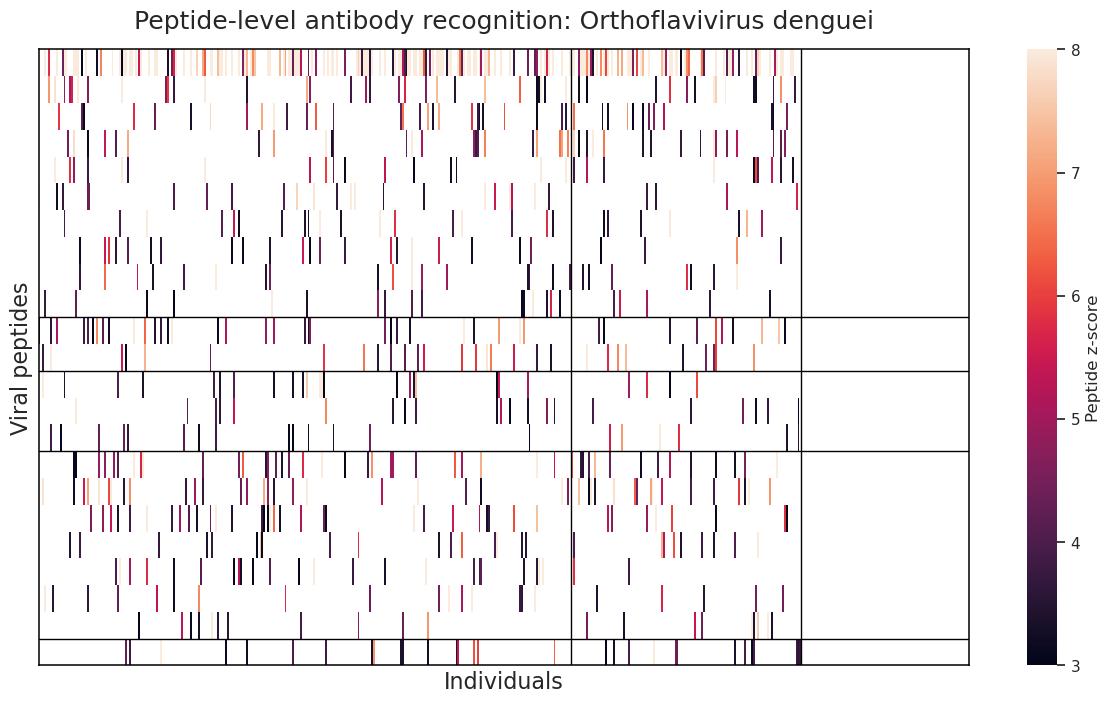

In [132]:
fig, ax = plt.subplots(
    figsize=(15,8)

)

sns.heatmap(
    target_matrix,

    vmin=3,
    vmax=8,

    yticklabels=False,
    xticklabels=False,

    linewidths=0,

    cbar_kws={
        'label': 'Peptide z-score'
    },

    ax=ax
)


#horizontal lines between protein groups
protein_sequence = (peptide_order['mature_protein'].to_list())

for i in range(len(protein_sequence) -1):
    if protein_sequence[i] != protein_sequence[i+1]: 
        ax.axhline(y=i +1, color='black', linewidth=1, zorder=10)

#verical lines between cohort groups

n_contact = len(c)
n_survivor = len(s)

ax.axvline(x=n_contact, color='black', linewidth=1, zorder=11)

ax.axvline(x=n_contact + n_survivor, color='black', linewidth=1, zorder=10)


ax.set_ylabel('Viral peptides', fontsize=16)
ax.set_xlabel('Individuals', fontsize=16)

ax.set_title(f'Peptide-level antibody recognition: {target}', fontsize=18, pad=15)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.1)

### which are the most seroprevalent DENV peptides and where do they map? 

In [133]:
long_denv.groupby('serotype')['peptide'].count()

serotype
DENV-1     968
DENV-2    5808
DENV-3    1452
DENV-4    1936
Name: peptide, dtype: int64

In [134]:
denv_ns5 = long_denv.loc[long_denv['mature_protein'] == 'RNA-dependent RNA polymerase NS5']
denv_ns5.sort_values(by='frac_reactive', ascending=False).drop_duplicates(subset='peptide', keep='first')

,peptide,individual,z_score,rpk,sequence,species,genus,family,protein_std,accession,...,ref_start,ref_end,mature_protein,protein_start,protein_end,identity,n_aligned,mapping_confident,serotype,frac_reactive
4453,WLD55688.1|polyprotein|dengue_virus_type_2|iso...,C-124-1_3_C1,-0.096570,0.176256,SWMEDKTPVTTWEDVPYLGKREDQWCGSLIGLTSRATWAQNILTAI,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polymerase,WLD55688.1,...,3314.0,3358.0,RNA-dependent RNA polymerase NS5,823.0,867.0,0.844444,45.0,True,DENV-2,0.478589
33,WEG68663.1|polyprotein|dengue_virus_type_1|iso...,C-111-3_3_I6,-1.449098,0.000000,IFKLTYQNKVVRVQRPAKNGTVMDVISRRDQRGSGQVGTYGLNTFT,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polymerase,WEG68663.1,...,3059.0,3104.0,RNA-dependent RNA polymerase NS5,568.0,613.0,0.913043,46.0,True,DENV-1,0.110831
38,WMV06615.1|polyprotein|dengue_virus_type_1|iso...,C-111-3_3_I6,-0.606545,0.635302,RQLNQLSKSEFNTYKRSGITEVDRSEAKEGLKRGETTKHAVSRGTA,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polymerase,WMV06615.1,...,2508.0,2551.0,RNA-dependent RNA polymerase NS5,17.0,60.0,0.727273,44.0,True,DENV-1,0.100756
17,WVW36851.1|polyprotein|dengue_virus_type_2|iso...,C-109-3_4_E7,1.188425,3.396428,SKKEGGAMYADDTAGWDTRITLEDLKNEEMVTNHMEGEHKKLAEAI,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polymerase,WVW36851.1,...,3014.0,3059.0,RNA-dependent RNA polymerase NS5,523.0,568.0,1.000000,46.0,True,DENV-2,0.098237
11,WEG68698.1|polyprotein|dengue_virus_type_2|iso...,C-109-3_4_E7,-1.141513,0.000000,DLKNEEMVTNHMEGEHKKLAKAIFKLTYQNKVVRVQRPTPRGTVMD,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polymerase,WEG68698.1,...,3037.0,3082.0,RNA-dependent RNA polymerase NS5,546.0,591.0,0.978261,46.0,True,DENV-2,0.068010
11070,QCH40796.1|polyprotein|dengue_virus_type_2|iso...,HBDB-109,-0.010739,0.661172,HAKHEWMTTEDMMTVWNRVWIQENPWMEDKTPVESWEEIPYLGKRE,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polymerase,QCH40796.1,...,3289.0,3334.0,RNA-dependent RNA polymerase NS5,798.0,843.0,0.978261,46.0,True,DENV-2,0.065491
121,AXX75612.1|polyprotein|dengue_virus_type_3|iso...,C-140-1_1_A7,-1.417849,0.000000,PEGRVIDLGCGRGGWSYYCAGLKKVTEVRGYTKGGPGHEEPVPMST,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polyprotein,AXX75612.1,...,2564.0,2609.0,RNA-dependent RNA polymerase NS5,73.0,118.0,0.826087,46.0,True,DENV-3,0.062972
113,XQH47600.1|polyprotein|dengue_virus_type_4|iso...,C-135-2_1_D2,0.075220,0.720015,WSGVEGEGLHRLGYILEDIDKKDGDLIYADDTAGWDTRITEDDLLN,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polymerase,XQH47600.1,...,2996.0,3040.0,RNA-dependent RNA polymerase NS5,505.0,549.0,0.755556,45.0,True,DENV-4,0.062972
110,WXR65056.1|polyprotein|dengue_virus_type_4|iso...,C-135-2_1_D2,-1.366097,0.000000,WSGVEGEGLHRLGYILEEIDKKDGDLMYADDTAGWDTRITEDDLQN,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polymerase,WXR65056.1,...,2996.0,3040.0,RNA-dependent RNA polymerase NS5,505.0,549.0,0.755556,45.0,True,DENV-4,0.060453
116,AFZ40123.1|polyprotein|dengue_virus_type_2|iso...,C-140-1_1_A7,-1.213467,0.000000,SRPPWAKNFQPAINQVRSLLCNEESADFMPSMKRFRREEEEAGVLW,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polyprotein,AFZ40123.1,...,3346.0,3391.0,RNA-dependent RNA polymerase NS5,855.0,900.0,0.804348,46.0,True,DENV-2,0.052897


In [135]:
long_denv.sort_values(by='frac_reactive', ascending=False).drop_duplicates(subset='peptide', keep='first')

,peptide,individual,z_score,rpk,sequence,species,genus,family,protein_std,accession,...,ref_start,ref_end,mature_protein,protein_start,protein_end,identity,n_aligned,mapping_confident,serotype,frac_reactive
3004,WLD55688.1|polyprotein|dengue_virus_type_2|iso...,C-439-1_1_I5,9.199847,9.679094,SWMEDKTPVTTWEDVPYLGKREDQWCGSLIGLTSRATWAQNILTAI,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polymerase,WLD55688.1,...,3314.0,3358.0,RNA-dependent RNA polymerase NS5,823.0,867.0,0.844444,45.0,True,DENV-2,0.478589
10125,AMN88556.1|polyprotein|Dengue_virus|isolate=Br...,HBDB-053,-0.474672,0.938566,ARGYISTRVGMGEAAAIFMTATPPGSAEAFPQSNSVIYDEEKDIPE,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polyprotein,AMN88556.1,...,1771.0,1816.0,nonstructural protein NS3,296.0,341.0,0.782609,46.0,True,NaN,0.110831
10,WEG68663.1|polyprotein|dengue_virus_type_1|iso...,C-109-3_4_E7,0.106413,0.720274,IFKLTYQNKVVRVQRPAKNGTVMDVISRRDQRGSGQVGTYGLNTFT,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polymerase,WEG68663.1,...,3059.0,3104.0,RNA-dependent RNA polymerase NS5,568.0,613.0,0.913043,46.0,True,DENV-1,0.110831
11118,UDI89630.1|polyprotein|dengue_virus_type_2|iso...,HBDB-115,0.015783,0.341460,HLTTRNGEPHMIVSKNEKGKSLLFKTENGINMCTLMAMDLGELCED,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polymerase,UDI89630.1,...,116.0,161.0,membrane glycoprotein precursor prM,2.0,47.0,0.913043,46.0,True,DENV-2,0.103275
11122,WEG68698.1|polyprotein|dengue_virus_type_2|iso...,HBDB-115,-0.085138,0.853650,KEGEEVQVLALEPGKNPRAVQTKPGTFKTNTGTIGAVSLDFSPGTS,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polymerase,WEG68698.1,...,1565.0,1610.0,nonstructural protein NS3,90.0,135.0,0.956522,46.0,True,DENV-2,0.103275
11124,WMV06615.1|polyprotein|dengue_virus_type_1|iso...,HBDB-115,-0.290275,0.853650,RQLNQLSKSEFNTYKRSGITEVDRSEAKEGLKRGETTKHAVSRGTA,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polymerase,WMV06615.1,...,2508.0,2551.0,RNA-dependent RNA polymerase NS5,17.0,60.0,0.727273,44.0,True,DENV-1,0.100756
6296,WVW36851.1|polyprotein|dengue_virus_type_2|iso...,C-456-1_2_F2,-1.369744,0.000000,SKKEGGAMYADDTAGWDTRITLEDLKNEEMVTNHMEGEHKKLAEAI,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polymerase,WVW36851.1,...,3014.0,3059.0,RNA-dependent RNA polymerase NS5,523.0,568.0,1.000000,46.0,True,DENV-2,0.098237
22,XQH47600.1|polyprotein|dengue_virus_type_4|iso...,C-109-3_4_E7,0.998935,1.968317,GRIGRNPAQEDDQYVFSGDPLKNDEDHAHWTEAKMLLDNIYTPEGI,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polymerase,XQH47600.1,...,1934.0,1979.0,nonstructural protein NS3,459.0,504.0,0.760870,46.0,True,DENV-4,0.095718
10136,WVW36851.1|polyprotein|dengue_virus_type_2|iso...,HBDB-053,-0.321188,1.066785,AKATREAQKRAAAGIMKNPTVDGITVIDLDPIPYDPKFEKQLGQVM,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polymerase,WVW36851.1,...,2370.0,2415.0,nonstructural protein NS4B,127.0,172.0,1.000000,46.0,True,DENV-2,0.075567
12,WEG68698.1|polyprotein|dengue_virus_type_2|iso...,C-109-3_4_E7,0.802987,1.775811,HLTTRNGEPHMIVGRQEKGKSLLFKTEDGVNMCTLMAIDLGELCED,Orthoflavivirus denguei,Orthoflavivirus,Flaviviridae,polymerase,WEG68698.1,...,116.0,161.0,membrane glycoprotein precursor prM,2.0,47.0,0.956522,46.0,True,DENV-2,0.073048


### let's test how conserved this most seroprevalent peptide is across all serotypes!

In [136]:
most_prev_denv_pep_ns5 = 'SWMEDKTPVTTWEDVPYLGKREDQWCGSLIGLTSRATWAQNILTAI'

In [137]:
from Bio import SeqIO, AlignIO
from Bio.Align import PairwiseAligner
from collections import Counter
import numpy as np
import pandas as pd


### where do the most seroprevalent peptide for LASV map to? 

In [138]:
lasv = long.loc[long['species'] == 'Mammarenavirus lassaense']

lasv_pep_prevalence = (
    lasv[lasv['cohort'] == 'SL']
    .groupby('peptide', observed=True)['reactive']
    .mean().rename('frac_reactive')
)

top_lasv_peps = lasv_pep_prevalence.sort_values(ascending=False).head(15).index

In [139]:
long = long.set_index('peptide')

In [140]:
long.loc[top_lasv_peps]

,individual,z_score,rpk,sequence,species,genus,family,protein_std,accession,cohort,category,reactive,reactive_z
peptide,,,,,,,,,,,,,
AZI96407.1|nucleoprotein|Mammarenavirus_lassaense|LASV/H.sapiens-wt/NGA/2018/IRR_060|Homo_sapiens|Nigeria:_EBONYI|03-Feb-2018|S|?|tile_16,C-109-3_4_E7,9.822550,345.890093,KVGTTGSNKSLQSAGFPAGLTYSQLMTLKDSMMQLDPSAKTWIDIE,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,nucleoprotein,AZI96407.1,SL,Household contact,True,9.822550
AZI96407.1|nucleoprotein|Mammarenavirus_lassaense|LASV/H.sapiens-wt/NGA/2018/IRR_060|Homo_sapiens|Nigeria:_EBONYI|03-Feb-2018|S|?|tile_16,C-111-3_3_I6,11.622461,841.735649,KVGTTGSNKSLQSAGFPAGLTYSQLMTLKDSMMQLDPSAKTWIDIE,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,nucleoprotein,AZI96407.1,SL,Household contact,True,11.622461
AZI96407.1|nucleoprotein|Mammarenavirus_lassaense|LASV/H.sapiens-wt/NGA/2018/IRR_060|Homo_sapiens|Nigeria:_EBONYI|03-Feb-2018|S|?|tile_16,C-112-1_3_B3,2.057321,6.534561,KVGTTGSNKSLQSAGFPAGLTYSQLMTLKDSMMQLDPSAKTWIDIE,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,nucleoprotein,AZI96407.1,SL,Household contact,False,NaN
AZI96407.1|nucleoprotein|Mammarenavirus_lassaense|LASV/H.sapiens-wt/NGA/2018/IRR_060|Homo_sapiens|Nigeria:_EBONYI|03-Feb-2018|S|?|tile_16,C-130-2_3_C3,3.106904,11.643128,KVGTTGSNKSLQSAGFPAGLTYSQLMTLKDSMMQLDPSAKTWIDIE,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,nucleoprotein,AZI96407.1,SL,Household contact,True,3.106904
AZI96407.1|nucleoprotein|Mammarenavirus_lassaense|LASV/H.sapiens-wt/NGA/2018/IRR_060|Homo_sapiens|Nigeria:_EBONYI|03-Feb-2018|S|?|tile_16,C-135-2_1_D2,4.610025,25.533138,KVGTTGSNKSLQSAGFPAGLTYSQLMTLKDSMMQLDPSAKTWIDIE,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,nucleoprotein,AZI96407.1,SL,Household contact,True,4.610025
...,...,...,...,...,...,...,...,...,...,...,...,...,...
UCR17173.1|polymerase|Mammarenavirus_lassaense|H.sapiens-wt/NGA/2018/NML_55|Homo_sapiens|Nigeria|2018|?|?|tile_10,HBDB-106,0.551095,0.762519,DNRTDHYEDIIALCHQGINNKLSAYEVKMQIEEEYQVFRNRIRQGE,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,polymerase,UCR17173.1,HBDB,US healthy,False,NaN
UCR17173.1|polymerase|Mammarenavirus_lassaense|H.sapiens-wt/NGA/2018/NML_55|Homo_sapiens|Nigeria|2018|?|?|tile_10,HBDB-107,-0.530271,0.235851,DNRTDHYEDIIALCHQGINNKLSAYEVKMQIEEEYQVFRNRIRQGE,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,polymerase,UCR17173.1,HBDB,US healthy,False,NaN
UCR17173.1|polymerase|Mammarenavirus_lassaense|H.sapiens-wt/NGA/2018/NML_55|Homo_sapiens|Nigeria|2018|?|?|tile_10,HBDB-109,-0.820192,0.124332,DNRTDHYEDIIALCHQGINNKLSAYEVKMQIEEEYQVFRNRIRQGE,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,polymerase,UCR17173.1,HBDB,US healthy,False,NaN


In [141]:
species_peptide_counts = (
    hits
    .groupby('species', observed=True)['peptide']
    .nunique()
    .reset_index(name='n_peptides')
    .sort_values('n_peptides', ascending=False)
)

display(species_peptide_counts.head(30))

,species,n_peptides
90,Mammarenavirus lassaense,76
182,Orthonairovirus haemorrhagiae,39
134,Orthoflavivirus denguei,32
124,Nairoviridae sp.,20
178,Orthonairovirus erveense,17
83,Mammarenavirus choriomeningitidis,16
365,unidentified Reptarenavirus,14
200,Orthonairovirus sakhalinense,12
113,Mammarenavirus whitewaterense,11
122,Morbillivirus hominis,11


In [142]:
peps_metadata = peps_metadata.reset_index().copy()

In [143]:
species_pep_counts_library = peps_metadata.groupby('species')['peptide'].nunique().reset_index(name='n_peptides_full_library')

In [144]:
species_pep_counts_library

,species,n_peptides_full_library
0,Academ virus,66
1,Actinovirus bernense,171
2,Actinovirus halieutaeae,53
3,Actinovirus triacanthodis,157
4,Aershan mammarenavirus,96
...,...,...
460,Yunnan shrew mammarenavirus 1,132
461,Yunnan shrew orthonairovirus 1,248
462,Yunnan shrew orthonairovirus 2,27
463,Zika virus vector pZIKV-ICD,12


In [145]:
species_peptide_counts = species_peptide_counts.merge(species_pep_counts_library[['species', 'n_peptides_full_library']], on='species', how='left')

In [146]:
species_peptide_counts['normalized_hits_fraction_perc'] = (species_peptide_counts['n_peptides'] / species_peptide_counts['n_peptides_full_library'] * 100).round(2)

In [147]:
species_peptide_counts.to_csv(
    f'{FIG_DIR}/Supplementary_Table_species_peptide_counts_hits.csv',
    index=False
)

In [148]:
species_peptide_counts.sort_values(by='n_peptides_full_library', ascending=False).head(30)

,species,n_peptides,n_peptides_full_library,normalized_hits_fraction_perc
0,Mammarenavirus lassaense,76,4494,1.69
1,Orthonairovirus haemorrhagiae,39,2524,1.55
5,Mammarenavirus choriomeningitidis,16,2267,0.71
2,Orthoflavivirus denguei,32,2050,1.56
6,unidentified Reptarenavirus,14,1418,0.99
3,Nairoviridae sp.,20,1160,1.72
4,Orthonairovirus erveense,17,1134,1.50
17,Mammarenavirus wenzhouense,9,864,1.04
10,Mammarenavirus lunaense,10,684,1.46
12,Uukuvirus uukuniemiense,10,663,1.51


# Figure 2 — Individual viral seroreactivity heatmap

**Question:** How are the population-level signals distributed across individuals?

The two species with the highest SL seroreactive prevalence within each viral family are shown. Species are grouped by family and ordered within each family by SL prevalence. Individuals are grouped as **Lassa survivors → household contacts → US healthy**, with hierarchical clustering performed separately within each outcome/reference group using the complete species-level maximum z-score profile.

For clustering, Euclidean distance and Ward linkage are used. The dendrograms are not displayed; clustering only determines the order of individuals.

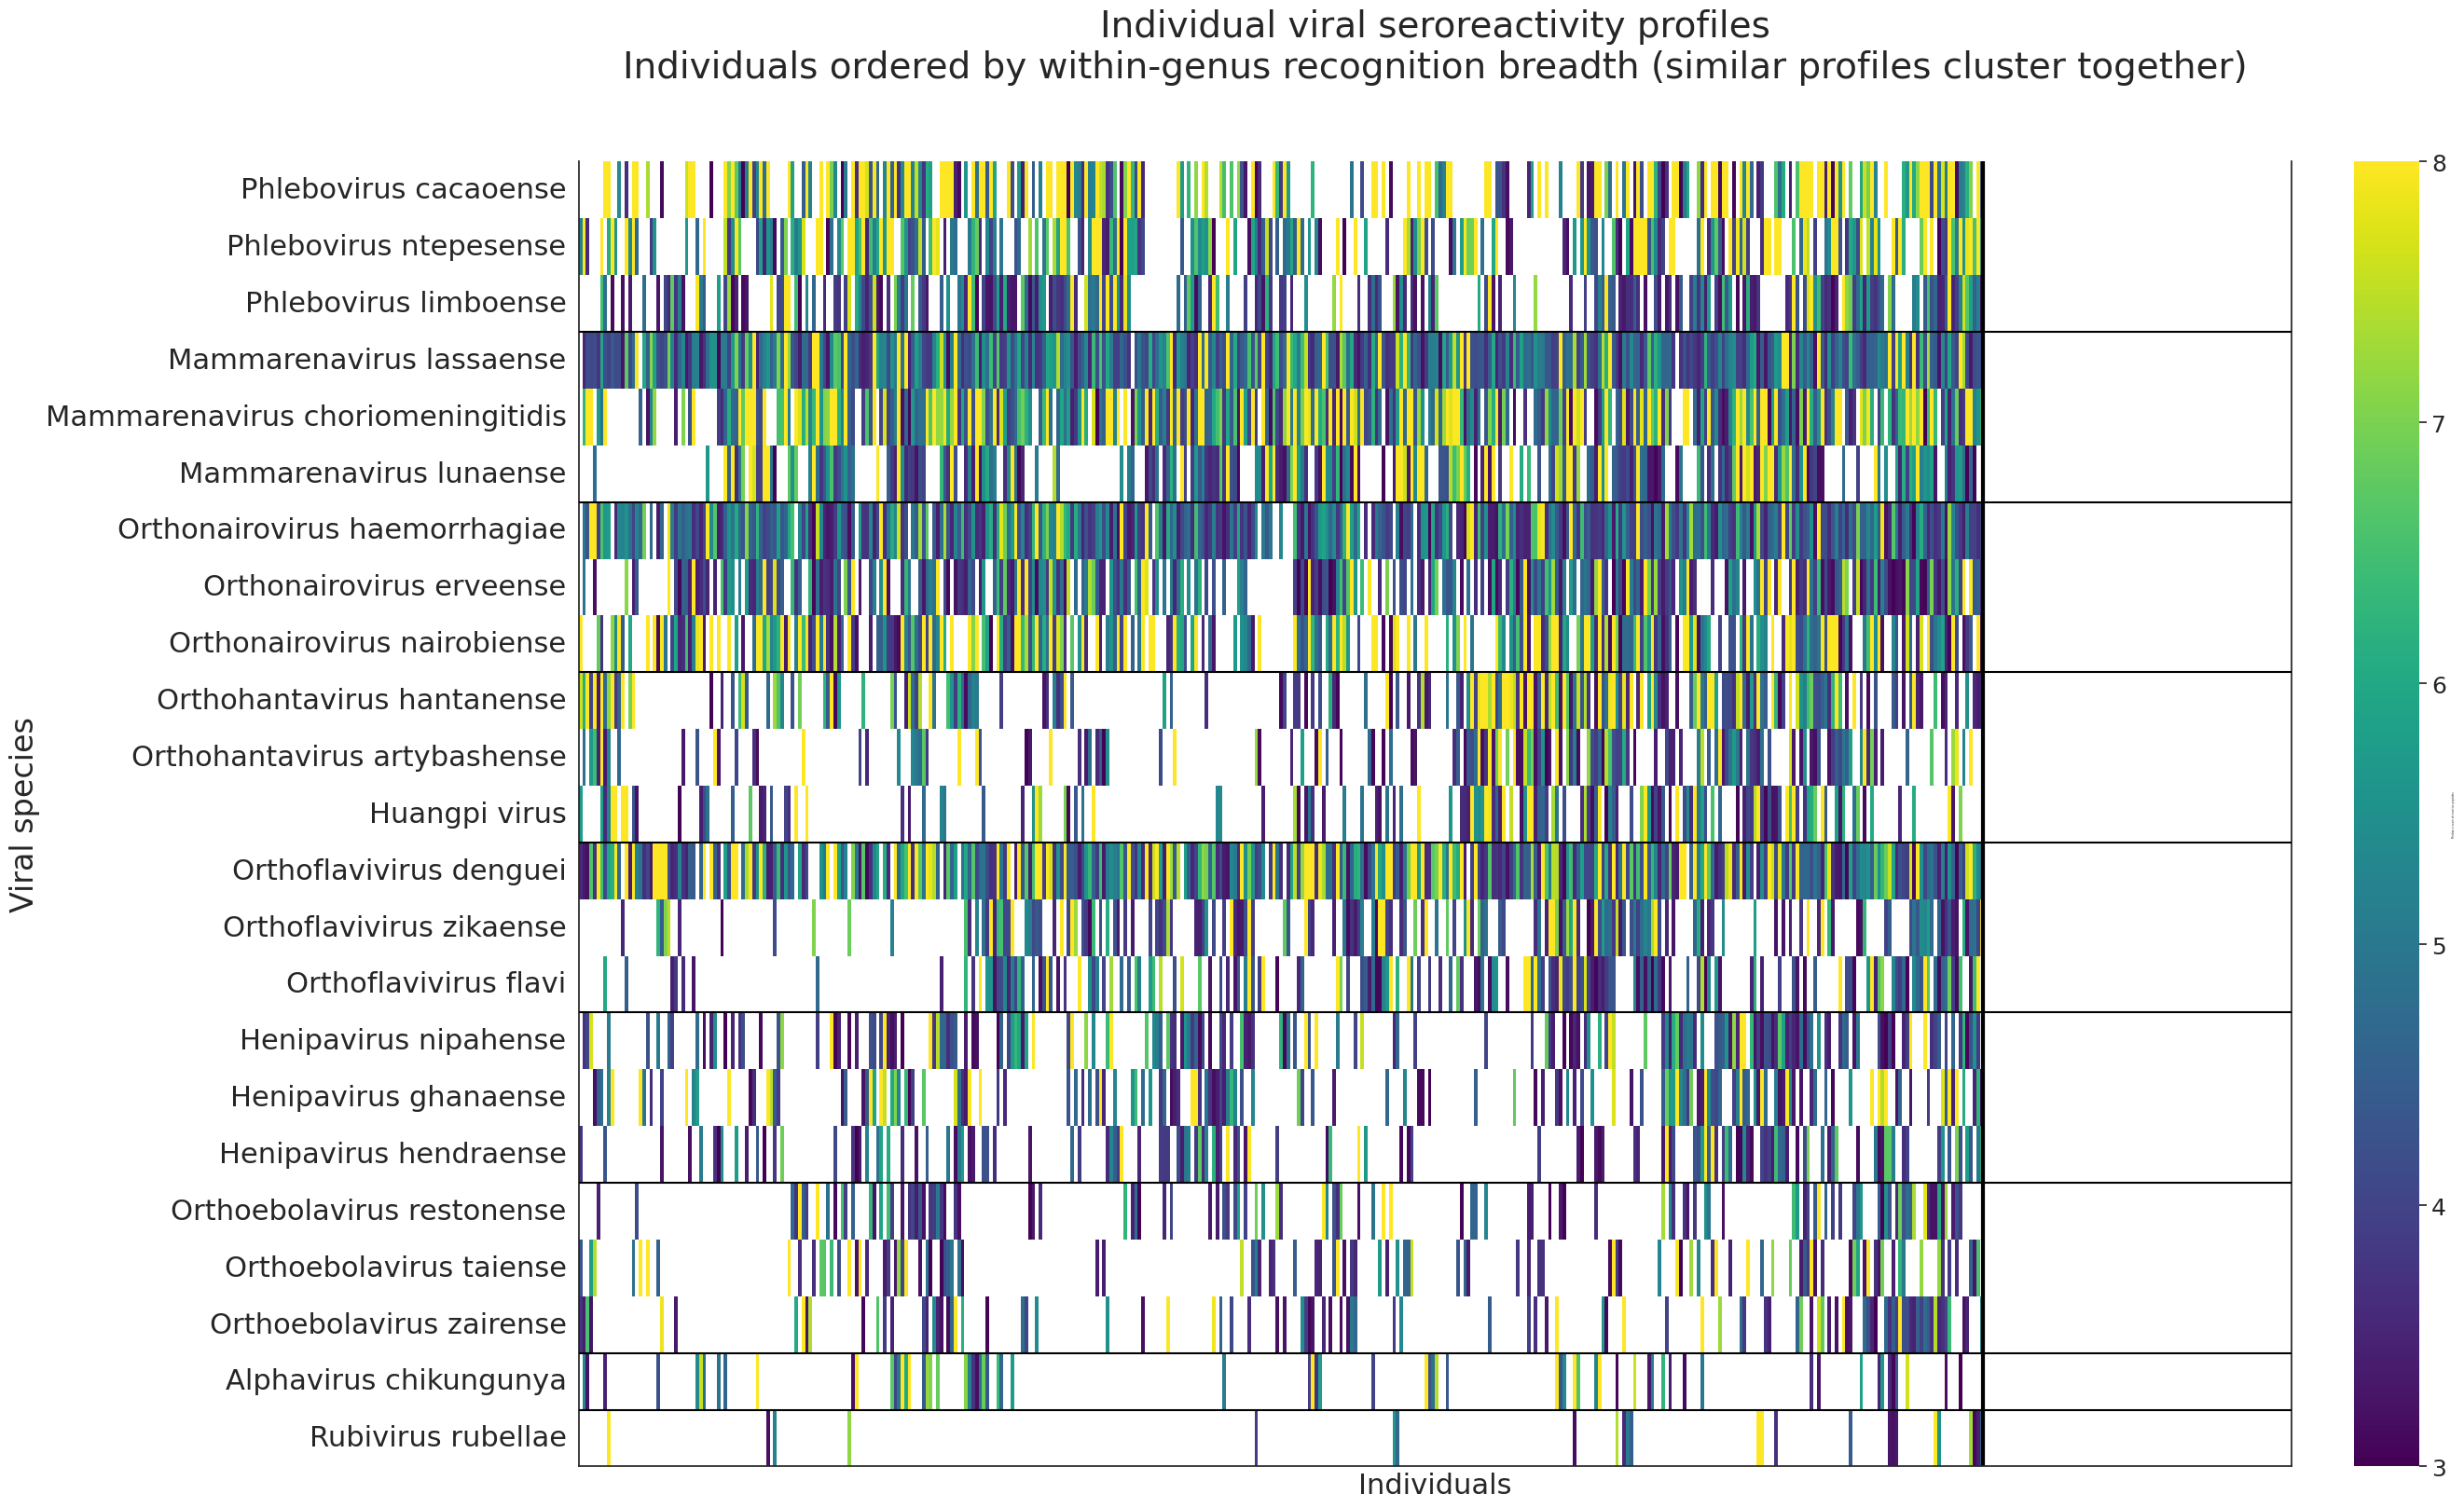

In [149]:

# FIGURE 2:
# INDIVIDUAL VIRAL SEROREACTIVITY HEATMAP
#
# MAIN HEATMAP VALUE:
#   Median z-score among reactive peptides
#   for each individual x species
#
# REACTIVITY:
#   peptide is reactive if z_score > 3
#
# SPECIES SELECTION:
#   Top 3 species within each Figure 1 representative genus,
#   ranked by SL seroprevalence
#
# INDIVIDUAL ORDERING:
#   Hierarchical clustering separately within each cohort,
#   based on within-genus recognition breadth
# Cohorts:
#   SL
#   US healthy (HBDB)
#
# IMPORTANT:
#   Within-genus recognition breadth suggests broader recognition
#   but does NOT by itself demonstrate antibody cross-reactivity.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import (
    linkage,
    leaves_list
)

TOP_N_SPECIES_PER_GENUS = 3

# Peptide-level reactivity threshold
REACTIVE_Z_THRESHOLD = 3

# Heatmap color scale
HEATMAP_VMIN = REACTIVE_Z_THRESHOLD
HEATMAP_VMAX = 8

# Figure dimensions
FIGURE_WIDTH = 35
FIGURE_HEIGHT = 20

#
# For each individual x species:
#
# median_reactive_z:
#     median z-score among REACTIVE peptides only
#
# n_reactive_peptides:
#     number of reactive peptides
#
# seroreactive:
#     TRUE if at least one peptide is reactive
#
# Why median among reactive peptides?
#
# Taking the median across ALL peptides would dilute a real
# peptide-specific response with many nonreactive peptides.
#
# Max z-score is avoided because one extreme peptide can dominate
# the species-level signal.

long['reactive_z'] = ( #if peptide not reactive, reactive_z becomes NaN
    long['z_score'].where(long['reactive'])
)

species_individual = (long.groupby(
        ['species','individual','cohort','genus','family'], observed=True)
    .agg(
        median_reactive_z = ('reactive_z', 'median'), 
        n_reactive_peptides = ('reactive', 'sum'), 
        seroreactive= ('reactive', 'any')
    ).reset_index()
)

# SPECIES PREVALENCE IN SL
#
# This is used to select the top species within each
# representative genus.

sl_species_prev = (
    species_individual[species_individual['cohort'] == 'SL'
    ].groupby(
        ['species','genus','family'],
        observed=True
    )['seroreactive' ].mean() #this is the fraction of cohort being seroreactive to the species -> SL prevalence
    .reset_index(name='SL_prevalence')
)

# KEEP SPECIES BELONGING TO FIGURE 1 GENERA

species_candidates = (sl_species_prev[sl_species_prev['genus'].isin(representative_genera)].copy()
)
# Highest SL seroprevalence first.

selected_species_df = (species_candidates.sort_values(['genus','SL_prevalence'],ascending=[True,False]
    ).groupby('genus',observed=True)
    .head(TOP_N_SPECIES_PER_GENUS).copy()
)


# SPECIES ORDER
#
# First:
#     Figure 1 genus order: genus_order
#
# Then within genus:
#     descending SL prevalence

heatmap_genus_order = genus_order[::-1] #reverse genus order so it matches the barplot order

species_order = []

for genus in heatmap_genus_order:
    genus_species = (selected_species_df[selected_species_df['genus'] == genus]
        .sort_values('SL_prevalence',ascending=False)['species'].tolist())
    species_order.extend(genus_species) #genus_species is itself a list, want to add each species from that list individually into species_order

# DISPLAYED HEATMAP:
#
#  median z-score among reactive peptides
#
# Nonreactive individual x species combinations are NaN.

heatmap_long = (species_individual[species_individual['species'].isin(species_order)].copy())

species_person_z = (heatmap_long
    .pivot(index='species',columns='individual',values='median_reactive_z'
    ).reindex(species_order))

# TRUE:
#     at least one reactive peptide
#
# FALSE:
#     no reactive peptides
#
# This is used to calculate within-genus recognition breadth.

species_person_reactive = (heatmap_long.pivot(index='species',columns='individual',values='seroreactive')
    .reindex(species_order).fillna(False).astype(bool)
)

individual_cohort = (
    heatmap_long[['individual','cohort']]
    .drop_duplicates('individual')
    .set_index('individual')['cohort']
)

species_person_reactive = (species_person_reactive[individual_cohort.index]
)

# cohort:
#     SL vs HBDB

sl_individuals = (individual_cohort[individual_cohort == 'SL']
        .index.tolist())

hbdb_individuals = (individual_cohort[individual_cohort == 'HBDB']
    .index.tolist()
)

species_to_genus = (selected_species_df.drop_duplicates('species'
    ).set_index('species').loc[species_order,'genus']
)

# 15. BUILD WITHIN-GENUS RECOGNITION BREADTH

#
# For each genus x individual:
#
#     number of selected species recognized
#
# With three species per genus:
#
#     0 = no species recognized
#     1 = one species recognized
#     2 = two species recognized
#     3 = three species recognized
#
# This is used ONLY for clustering individuals.
#
# The displayed heatmap remains the median reactive
# peptide z-score.

genus_breadth = (species_person_reactive.astype(int).groupby(species_to_genus,observed=True).sum())

# Match Figure 1 genus order
genus_breadth = (genus_breadth.reindex(genus_order))

# CLUSTERING FUNCTION

# Cluster individuals using genus-level recognition breadth.
#
# This means two individuals cluster together when they have
# similar patterns of:
#
#     0 / 1 / 2 / 3 recognized species
#
# across viral genera.

def order_individuals_by_genus_breadth(individual_list
):
    X = (genus_breadth[individual_list].fillna(0).T)

    linkage_matrix = linkage( X, method='ward', metric='euclidean') #linkage matrix compares breadth of species seroreactivity for each genus between individuals
    #ward clustering groups individuals whose overall patterns across genera are similar

    ordered_idx = (leaves_list(linkage_matrix)) #gets an ordering from the clustering tree

    ordered_individuals = (X.index[ordered_idx].tolist()) #that's the order to use for the heatmap columns

    return (ordered_individuals,linkage_matrix)

# CLUSTER EACH COHORT SEPARATELY

sl_ordered, sl_linkage = (order_individuals_by_genus_breadth(sl_individuals))

hbdb_ordered, hbdb_linkage = (order_individuals_by_genus_breadth(hbdb_individuals))

#final order for heatmap
ordered_individuals = (sl_ordered+hbdb_ordered)

# FINAL DISPLAY MATRIX
#
# The displayed heatmap uses MEDIAN REACTIVE Z-SCORE.
# We only clip the upper end.
# We do NOT clip the lower end because all displayed values
# are already based on reactive peptides. (so vmin is at least 3)

plot_matrix = (species_person_z[ordered_individuals].clip(upper=HEATMAP_VMAX))

genus_breadth_plot = (genus_breadth[ordered_individuals].reindex(genus_order))

species_metadata = (selected_species_df.drop_duplicates('species').set_index('species')
    .loc[plot_matrix.index]
)
genus_sequence = (species_metadata['genus'].tolist())

from itertools import groupby 

# COHORT BOUNDARIES

n_sl = len(
    sl_ordered
)

n_hbdb = len(
    hbdb_ordered
)

# CREATE FIGURE

fig = plt.figure(figsize=(FIGURE_WIDTH,FIGURE_HEIGHT))

# MAIN HEATMAP AXIS -> says where in the figure the heatmap should be displayed left, bottom, width, height

ax_heat = fig.add_axes(
    [0.18,0.10,0.64,0.70]
)
#  MAIN HEATMAP

# Median z-score among reactive peptides.
# ============================================================

sns.heatmap(
    plot_matrix,
    ax=ax_heat,
    cmap='viridis',
    vmin=HEATMAP_VMIN,
    vmax=HEATMAP_VMAX,
    xticklabels=False,
    yticklabels=True,
    linewidths=0,
    cbar_kws={
        'label':'Median z-score of reactive peptides','pad':0.03
    }
)

for i in range(len(genus_sequence) -1):
    if genus_sequence[i] != genus_sequence[i+1]:
        ax_heat.axhline(
            i+1, color='black', linewidth=1.5, zorder=10
        )


# SPECIES LABELS

ax_heat.set_yticklabels(
    plot_matrix.index,
    fontsize=22,
    rotation=0
)

ax_heat.set_ylabel(
    'Viral species',
    fontsize=24
)

ax_heat.set_xlabel(
    'Individuals',
    fontsize=22
)
# COHORT BOUNDARIES

ax_heat.axvline(
    x=n_sl,
    color='black',
    linewidth=3
)

# MAIN TITLE

ax_heat.set_title(
    ('Individual viral seroreactivity profiles\n' 'Individuals ordered by within-genus recognition breadth (similar profiles cluster together)'
    ),
    fontsize=28,pad=65 #pad constrols distance between the title and the top of the axes, measured in points
)

# COLORBAR

cbar = (ax_heat.collections[0].colorbar) #collections[0] is the first graphical object stored on the axes

cbar.ax.tick_params(
    labelsize=18)

cbar.set_label('Median z-score of reactive peptides',fontsize=2)

# 
# CLEAN UP
# remove border lines around matplotlib axis
sns.despine(
    ax=ax_heat,
    right=False)


# 38. SAVE

fig.savefig(
    f'{FIG_DIR}/Figure2_individual_species_heatmap_genus_breadth_medianZ.png',dpi=300,
    bbox_inches='tight'
)

plt.show()

# Figure 3: LASV ELISA data X PhIP-Seq seropositivity data 
**question:** does the LASV ELISA data reflect the seropositivity observed in the SL cohort? 
 an individual is defined LASV seropositive by PhIP-Seq, if at least one retained peptide passed z > 3. 

In [150]:
lasv_elisa_data = pd.read_csv(LASV_ELISA_FILE).set_index('species')
lasv_elisa_data.drop(columns='Unnamed: 0', inplace=True)

In [151]:
lasv = long[
    long['species'] == 'Mammarenavirus lassaense'
].copy()

lasv_seroreactive = (
    lasv.groupby('individual', as_index=False) #as_index =False to remain a regular column in the resulting dataframe
    .agg(
        n_LASV_reactive_peptides=('reactive', 'sum'),
        LASV_seroreactive=('reactive', 'any'), 
        LASV_median_reactive_z=('reactive_z', 'median'), 
        LASV_max_reactive_z=('reactive_z', 'max'), 
        LASV_sum_reactive_z=('reactive_z', 'sum')
    )
)

lasv_np = lasv[lasv['protein_std'] == 'nucleoprotein'].copy()

np_summary = (
    lasv_np.groupby('individual', as_index=False)
    .agg(
        LASV_num_np_reactive=('reactive', 'sum'), 
        LASV_np_seroreactive=('reactive', 'any'), 
        LASV_median_np_reactive_z=('reactive_z', 'median'), 
        LASV_max_np_reactive_z=('reactive_z', 'max'), 
        LASV_sum_np_reactive_z=('reactive_z', 'sum')
    )
)

lasv_gp = lasv[lasv['protein_std'] == 'glycoprotein'].copy()

gp_summary = (
    lasv_np.groupby('individual', as_index=False)
    .agg(
        LASV_num_gp_reactive=('reactive', 'sum'), 
        LASV_gp_seroreactive=('reactive', 'any'), 
        LASV_median_gp_reactive_z=('reactive_z', 'median'), 
        LASV_max_gp_reactive_z=('reactive_z', 'max'), 
        LASV_sum_gp_reactive_z=('reactive_z', 'sum')
    )
)

lasv_seroreactive = lasv_seroreactive.merge(
    np_summary, on='individual', how='left'
).merge(gp_summary, on='individual', how='left')


#for ppl with no reactive NP / GP peptides, will get NaN. Turn this into zero. 

lasv_seroreactive[['LASV_num_np_reactive', 'LASV_num_gp_reactive']] = (lasv_seroreactive[['LASV_num_np_reactive', 'LASV_num_gp_reactive']].fillna(0).astype(int))

In [152]:
lasv_concordance = lasv_elisa_data.merge(
    lasv_seroreactive, 
    on='individual', 
    how='left'
)

In [153]:
lasv_concordance['Serology_Result_Corrected'].value_counts(dropna=False)

Serology_Result_Corrected
Positive    347
Negative     50
Name: count, dtype: int64

In [154]:
lasv_concordance['NP_FINAL_RESULT'] = (lasv_concordance['NP_FINAL_RESULT'].replace('x', np.nan))

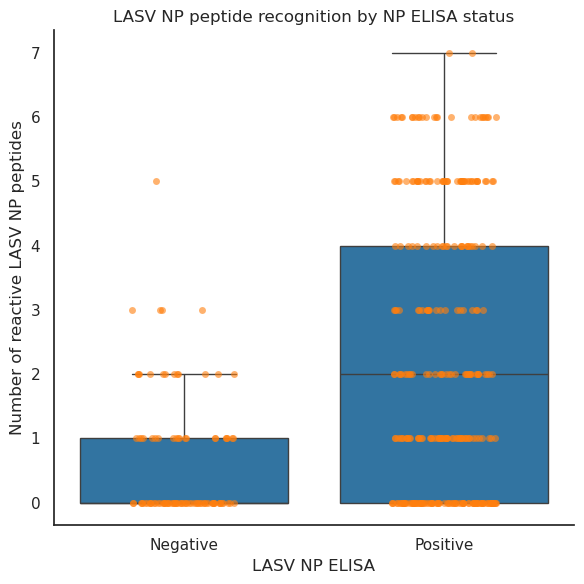

In [155]:
fig, ax = plt.subplots(figsize=(6, 6))

sns.boxplot(
    data=lasv_concordance,
    x='NP_FINAL_RESULT',
    y='LASV_num_np_reactive',
    showfliers=False,
    ax=ax
)

sns.stripplot(
    data=lasv_concordance,
    x='NP_FINAL_RESULT',
    y='LASV_num_np_reactive',
    jitter=0.2,
    alpha=0.6,
    ax=ax
)

ax.set_xlabel('LASV NP ELISA')
ax.set_ylabel('Number of reactive LASV NP peptides')
ax.set_title('LASV NP peptide recognition by NP ELISA status')

sns.despine()
plt.tight_layout()
plt.show()

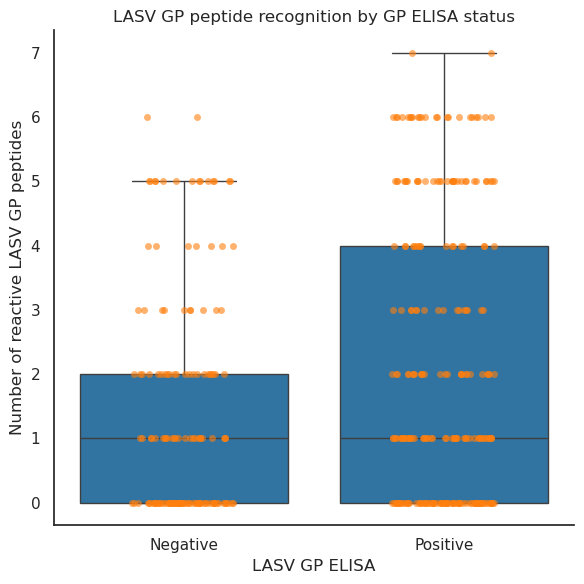

In [156]:
fig, ax = plt.subplots(figsize=(6, 6))

sns.boxplot(
    data=lasv_concordance,
    x='GP_FINAL_RESULT',
    y='LASV_num_gp_reactive',
    showfliers=False,
    ax=ax
)

sns.stripplot(
    data=lasv_concordance,
    x='GP_FINAL_RESULT',
    y='LASV_num_gp_reactive',
    jitter=0.2,
    alpha=0.6,
    ax=ax
)

ax.set_xlabel('LASV GP ELISA')
ax.set_ylabel('Number of reactive LASV GP peptides')
ax.set_title('LASV GP peptide recognition by GP ELISA status')

sns.despine()
plt.tight_layout()
plt.show()

In [157]:
#match Negative / Positive from ELISA data
lasv_concordance['PhIP-Seq result'] = (
    lasv_concordance['LASV_seroreactive']
    .map({True: 'Positive', False:'Negative'})
)

In [158]:
lasv_concordance.groupby('Serology_Result_Corrected')[
    'n_LASV_reactive_peptides'
].agg(['count', 'median', 'mean', 'std', 'min', 'max'])

,count,median,mean,std,min,max
Serology_Result_Corrected,,,,,,
Negative,50,5.0,5.200000,3.458205,0,14
Positive,347,7.0,7.677233,4.517100,0,27


In [159]:
lasv_concordance.groupby('Serology_Result_Corrected')[
    'n_LASV_reactive_peptides'
].agg(
    n='count',
    median='median',
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75)
)

,n,median,Q1,Q3
Serology_Result_Corrected,,,,
Negative,50,5.0,3.0,6.0
Positive,347,7.0,4.0,10.0


In [164]:
from scipy.stats import mannwhitneyu

neg = lasv_concordance.loc[
    lasv_concordance['Serology_Result_Corrected'] == 'Negative',
    'n_LASV_reactive_peptides'
]

pos = lasv_concordance.loc[
    lasv_concordance['Serology_Result_Corrected'] == 'Positive',
    'n_LASV_reactive_peptides'
]

mannwhitneyu(pos, neg, alternative='two-sided')

MannwhitneyuResult(statistic=np.float64(11624.0), pvalue=np.float64(9.698789032538046e-05))

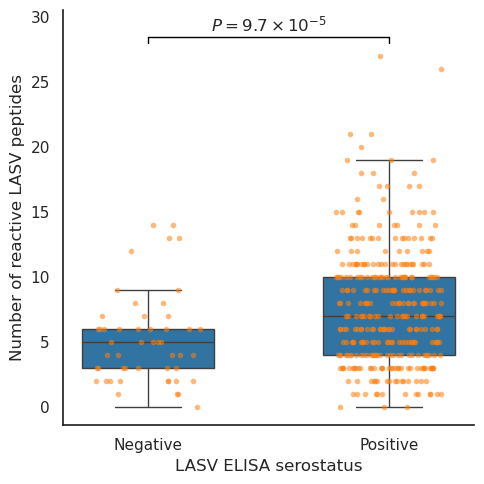

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(5, 5))

order = ['Negative', 'Positive']

sns.boxplot(
    data=lasv_concordance,
    x='Serology_Result_Corrected',
    y='n_LASV_reactive_peptides',
    order=order,
    showfliers=False,
    width=0.55,
    ax=ax
)

sns.stripplot(
    data=lasv_concordance,
    x='Serology_Result_Corrected',
    y='n_LASV_reactive_peptides',
    order=order,
    jitter=0.22,
    alpha=0.55,
    size=4,
    ax=ax
)

ax.set_xlabel('LASV ELISA serostatus')
ax.set_ylabel('Number of reactive LASV peptides')

# Statistical annotation
ymax = lasv_concordance['n_LASV_reactive_peptides'].max()
y = ymax + 1

ax.plot([0, 0, 1, 1], [y, y+0.4, y+0.4, y], c='black', lw=1)
ax.text(
    0.5, y + 0.6,
    r'$P = 9.7 \times 10^{-5}$',
    ha='center',
    va='bottom'
)

ax.set_ylim(top=y + 2.5)

sns.despine()
plt.tight_layout()
plt.show()

In [200]:
lasv_concordance['PhIP_NP_or_GP'] = (lasv_concordance['LASV_np_seroreactive'] | lasv_concordance['LASV_gp_seroreactive'])

In [205]:
lasv_concordance['PhIP_any_LASV'] = lasv_concordance['LASV_seroreactive']

In [208]:
pd.crosstab(
    lasv_concordance['Serology_Result_Corrected'], lasv_concordance['PhIP_NP_or_GP']
)

PhIP_NP_or_GP,False,True
Serology_Result_Corrected,,
Negative,33,17
Positive,119,228


In [209]:
pd.crosstab(
    lasv_concordance['Serology_Result_Corrected'], lasv_concordance['PhIP_any_LASV']
)

PhIP_any_LASV,False,True
Serology_Result_Corrected,,
Negative,1,49
Positive,3,344


In [211]:
lasv_concordance.columns

Index(['individual', 'cohort', 'sum_rpk', 'sum_zscore', 'log10_sum_rpk',
       'log2_sum_rpk', 'Sample', 'Classification', 'Sample_Date',
       'NP_Calc_Conc', 'NP_FINAL_RESULT', 'GP_Calc_Conc', 'GP_FINAL_RESULT',
       'Neut_Percent', 'Neut_Result ', 'Serology_Result_Corrected',
       'Sample_Date_parsed', 'Month_Year', 'PhIP-Seq_seropositive_1SD',
       'PhIP-Seq_seropositive_max', 'n_LASV_reactive_peptides',
       'LASV_seroreactive', 'LASV_median_reactive_z', 'LASV_max_reactive_z',
       'LASV_sum_reactive_z', 'LASV_num_np_reactive', 'LASV_np_seroreactive',
       'LASV_median_np_reactive_z', 'LASV_max_np_reactive_z',
       'LASV_sum_np_reactive_z', 'LASV_num_gp_reactive',
       'LASV_gp_seroreactive', 'LASV_median_gp_reactive_z',
       'LASV_max_gp_reactive_z', 'LASV_sum_gp_reactive_z', 'PhIP-Seq result',
       'concordance', 'PhIP_LASV_status', 'PhIP_NP_or_GP', 'PhIP_any_LASV'],
      dtype='object')

In [215]:
elisa_pos.columns

Index(['individual', 'cohort', 'sum_rpk', 'sum_zscore', 'log10_sum_rpk',
       'log2_sum_rpk', 'Sample', 'Classification', 'Sample_Date',
       'NP_Calc_Conc', 'NP_FINAL_RESULT', 'GP_Calc_Conc', 'GP_FINAL_RESULT',
       'Neut_Percent', 'Neut_Result ', 'Serology_Result_Corrected',
       'Sample_Date_parsed', 'Month_Year', 'PhIP-Seq_seropositive_1SD',
       'PhIP-Seq_seropositive_max', 'n_LASV_reactive_peptides',
       'LASV_seroreactive', 'LASV_median_reactive_z', 'LASV_max_reactive_z',
       'LASV_sum_reactive_z', 'LASV_num_np_reactive', 'LASV_np_seroreactive',
       'LASV_median_np_reactive_z', 'LASV_max_np_reactive_z',
       'LASV_sum_np_reactive_z', 'LASV_num_gp_reactive',
       'LASV_gp_seroreactive', 'LASV_median_gp_reactive_z',
       'LASV_max_gp_reactive_z', 'LASV_sum_gp_reactive_z', 'PhIP-Seq result',
       'concordance', 'PhIP_LASV_status', 'PhIP_NP_or_GP', 'PhIP_any_LASV'],
      dtype='object')

In [219]:
#calculate sensitivity

elisa_pos = (lasv_concordance[lasv_concordance['Serology_Result_Corrected'] == 'Positive'])
np_sensitivity = elisa_pos['LASV_np_seroreactive'].mean()
gp_sensitivity = elisa_pos['LASV_gp_seroreactive'].mean()
np_gp_sensitivity = elisa_pos['PhIP_NP_or_GP'].mean()
all_lasv_sensitiviity = elisa_pos['PhIP_any_LASV'].mean()

print(f'NP only: {np_sensitivity:.1f}, GP only: {gp_sensitivity:.1f}, NP and GP: {np_gp_sensitivity:.1f}, any lasv: {all_lasv_sensitiviity:.1f}')

NP only: 0.7, GP only: 0.7, NP and GP: 0.7, any lasv: 1.0


In [221]:
elisa_pos_no_np_gp = (elisa_pos[~elisa_pos['PhIP_NP_or_GP']].copy())
print('ELISA + individuals', len(elisa_pos))
print('ELISA+ with no reactive NP/GP peptide:', len(elisa_pos_no_np_gp))

ELISA + individuals 347
ELISA+ with no reactive NP/GP peptide: 119


In [222]:
n_elisa_pos = len(elisa_pos)
n_np_gp_pos = elisa_pos['PhIP_NP_or_GP'].sum()
n_no_np_gp = (~elisa_pos['PhIP_NP_or_GP']).sum()

print(n_np_gp_pos, n_no_np_gp, n_elisa_pos)

# percentages
pct_np_gp = n_np_gp_pos / n_elisa_pos * 100
pct_no_np_gp = n_no_np_gp / n_elisa_pos * 100

print(f'NP/GP peptide reactive: {pct_np_gp:.1f}%')
print(f'No NP/GP peptide reactive: {pct_no_np_gp:.1f}%')

228 119 347
NP/GP peptide reactive: 65.7%
No NP/GP peptide reactive: 34.3%


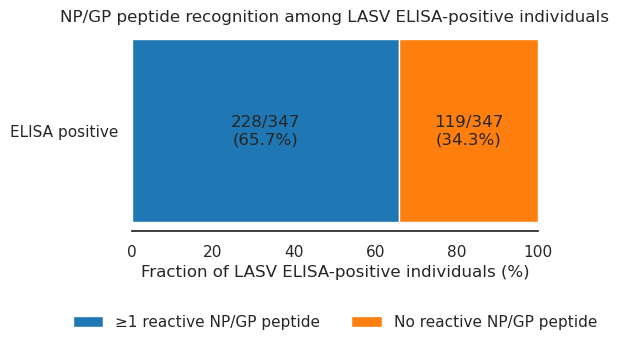

In [229]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.barh(
    y=['ELISA positive'],
    width=[pct_np_gp],
    left=0,
    label='≥1 reactive NP/GP peptide')

ax.barh(
    y=['ELISA positive'],
    width=[pct_no_np_gp],
    left=[pct_np_gp],
    label='No reactive NP/GP peptide')

# labels inside the bars
ax.text(
    pct_np_gp / 2,
    0,
    f'{n_np_gp_pos}/{n_elisa_pos}\n({pct_np_gp:.1f}%)',
    ha='center',
    va='center')

ax.text(
    pct_np_gp + pct_no_np_gp / 2,
    0,
    f'{n_no_np_gp}/{n_elisa_pos}\n({pct_no_np_gp:.1f}%)',
    ha='center',
    va='center')

ax.set_xlim(0, 100)

ax.set_xlabel(
    'Fraction of LASV ELISA-positive individuals (%)')

ax.set_title(
    'NP/GP peptide recognition among LASV ELISA-positive individuals')

ax.legend(
    frameon=False,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.35),
    ncol=2)

sns.despine(
    left=True)

plt.tight_layout()
plt.show()

In [226]:
elisa_pos_no_np_gp_ids = (
    elisa_pos_no_np_gp['individual'])

other_lasv_hits = (
    lasv[
        lasv['individual'].isin(elisa_pos_no_np_gp_ids)
        &
        lasv['reactive']
    ]
    .copy()
)

other_lasv_hits.groupby(
    'protein_std',
    observed=True
)['individual'].nunique()

protein_std
glycoprotein     35
polymerase      115
z protein        13
Name: individual, dtype: int64

In [ ]:
n_with_any_lasv = (
    elisa_pos_no_np_gp[
        'LASV_seroreactive'].sum()
)

print(n_with_any_lasv, '/',
    len(elisa_pos_no_np_gp)
)

116 / 119


## which proteins account for the ELISA negative signal?

In [166]:
lasv_person_protein = (lasv.groupby(['individual', 'protein_std'], observed=True)
                       .agg(n_reactive_peptides = ('reactive', 'sum'))
                       .reset_index())

In [167]:
lasv_person_protein = (lasv_person_protein.merge(lasv_concordance[['individual', 'Serology_Result_Corrected']], on='individual', how='left'))

In [168]:
lasv_person_protein

,individual,protein_std,n_reactive_peptides,Serology_Result_Corrected
0,C-109-1_5_B3,glycoprotein,0,Negative
1,C-109-1_5_B3,nucleoprotein,0,Negative
2,C-109-1_5_B3,polymerase,7,Negative
3,C-109-1_5_B3,z protein,0,Negative
4,C-109-2_5_B5,glycoprotein,0,Negative
...,...,...,...,...
1931,S-513_SA3_I2,z protein,0,Positive
1932,S-514_SA3_C8,glycoprotein,3,Positive
1933,S-514_SA3_C8,nucleoprotein,5,Positive
1934,S-514_SA3_C8,polymerase,6,Positive


In [169]:
lasv_person_protein.groupby(['Serology_Result_Corrected', 'protein_std'], observed=True)['n_reactive_peptides'].agg(['count', 'median', 'mean'])

count  median      mean
Serology_Result_Corrected protein_std                           
Negative                  glycoprotein      50     0.0  0.220000
                          nucleoprotein     50     0.0  0.520000
                          polymerase        50     4.0  4.360000
                          z protein         50     0.0  0.100000
Positive                  glycoprotein     347     0.0  0.605187
                          nucleoprotein    347     1.0  2.051873
                          polymerase       347     4.0  4.884726
                          z protein        347     0.0  0.135447

In [170]:
lasv_person_protein

,individual,protein_std,n_reactive_peptides,Serology_Result_Corrected
0,C-109-1_5_B3,glycoprotein,0,Negative
1,C-109-1_5_B3,nucleoprotein,0,Negative
2,C-109-1_5_B3,polymerase,7,Negative
3,C-109-1_5_B3,z protein,0,Negative
4,C-109-2_5_B5,glycoprotein,0,Negative
...,...,...,...,...
1931,S-513_SA3_I2,z protein,0,Positive
1932,S-514_SA3_C8,glycoprotein,3,Positive
1933,S-514_SA3_C8,nucleoprotein,5,Positive
1934,S-514_SA3_C8,polymerase,6,Positive


In [171]:
lasv_person_protein['recognizes_protein'] = (
    lasv_person_protein['n_reactive_peptides'] > 0
)

protein_recognizers = (
    lasv_person_protein
    .groupby(
        ['Serology_Result_Corrected', 'protein_std'],
        observed=True
    )['recognizes_protein']
    .agg(
        n_recognizers='sum',
        prevalence='mean'
    )
)

display(protein_recognizers)

n_recognizers  prevalence
Serology_Result_Corrected protein_std                             
Negative                  glycoprotein              10    0.200000
                          nucleoprotein             17    0.340000
                          polymerase                48    0.960000
                          z protein                  5    0.100000
Positive                  glycoprotein             138    0.397695
                          nucleoprotein            228    0.657061
                          polymerase               337    0.971182
                          z protein                 45    0.129683

In [172]:
protein_plot = protein_recognizers.reset_index()

In [173]:
protein_plot['prevalence'] = protein_plot['prevalence'].round(3)

In [174]:
protein_plot

,Serology_Result_Corrected,protein_std,n_recognizers,prevalence
0,Negative,glycoprotein,10,0.200
1,Negative,nucleoprotein,17,0.340
2,Negative,polymerase,48,0.960
3,Negative,z protein,5,0.100
4,Positive,glycoprotein,138,0.398
5,Positive,nucleoprotein,228,0.657
6,Positive,polymerase,337,0.971
7,Positive,z protein,45,0.130


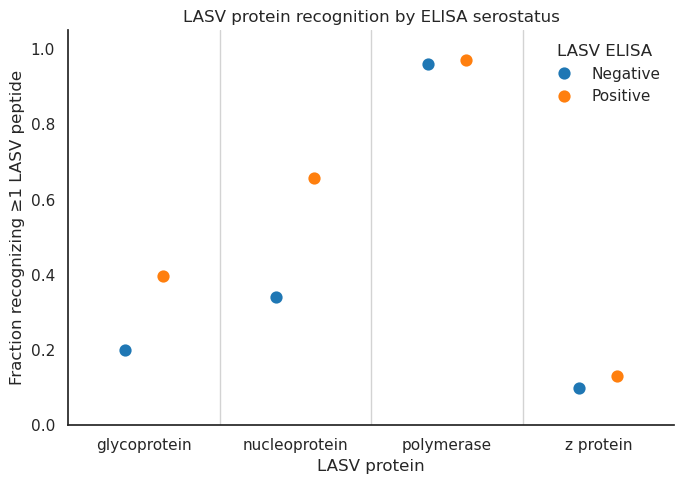

In [175]:
fig, ax = plt.subplots(figsize=(7, 5))

protein_order = [
    'glycoprotein',
    'nucleoprotein',
    'polymerase',
    'z protein'
]

sns.pointplot(
    data=protein_plot,
    x='protein_std',
    y='prevalence',
    hue='Serology_Result_Corrected',
    order=protein_order,
    dodge=0.25,
    linestyles='none',
    markers='o',
    ax=ax
)

# Vertical dividers between LASV proteins
for x in [0.5, 1.5, 2.5]:
    ax.axvline(
        x=x,
        color='lightgray',
        linewidth=1,
        zorder=0
    )

ax.set_ylim(0, 1.05)

ax.set_ylabel(
    'Fraction recognizing ≥1 LASV peptide'
)

ax.set_xlabel(
    'LASV protein'
)

ax.set_title(
    'LASV protein recognition by ELISA serostatus'
)

ax.legend(
    title='LASV ELISA',
    frameon=False
)

sns.despine()

plt.tight_layout()
plt.show()

In [176]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

results = []

for protein in [
    'glycoprotein',
    'nucleoprotein',
    'polymerase',
    'z protein'
]:

    sub = (
        lasv_person_protein[
            lasv_person_protein['protein_std'] == protein
        ]
    )

    neg = (
        sub.loc[
            sub['Serology_Result_Corrected'] == 'Negative',
            'n_reactive_peptides'
        ]
        .dropna()
    )

    pos = (
        sub.loc[
            sub['Serology_Result_Corrected'] == 'Positive',
            'n_reactive_peptides'
        ]
        .dropna()
    )

    u, p = mannwhitneyu(
        neg,
        pos,
        alternative='two-sided'
    )

    results.append({
        'protein': protein,

        'median_negative':
            neg.median(),

        'median_positive':
            pos.median(),

        'mean_negative':
            neg.mean(),

        'mean_positive':
            pos.mean(),

        'U':
            u,

        'p':
            p
    })


protein_tests = pd.DataFrame(
    results
)

protein_tests['p_FDR'] = (
    multipletests(
        protein_tests['p'],
        method='fdr_bh'
    )[1]
)

display(protein_tests)

,protein,median_negative,median_positive,mean_negative,mean_positive,U,p,p_FDR
0,glycoprotein,0.0,0.0,0.22,0.605187,6756.0,3.262879e-03,0.006526
1,nucleoprotein,0.0,1.0,0.52,2.051873,4996.0,5.183064e-07,0.000002
2,polymerase,4.0,4.0,4.36,4.884726,7915.0,3.137383e-01,0.418318
3,z protein,0.0,0.0,0.10,0.135447,8412.5,5.479749e-01,0.547975


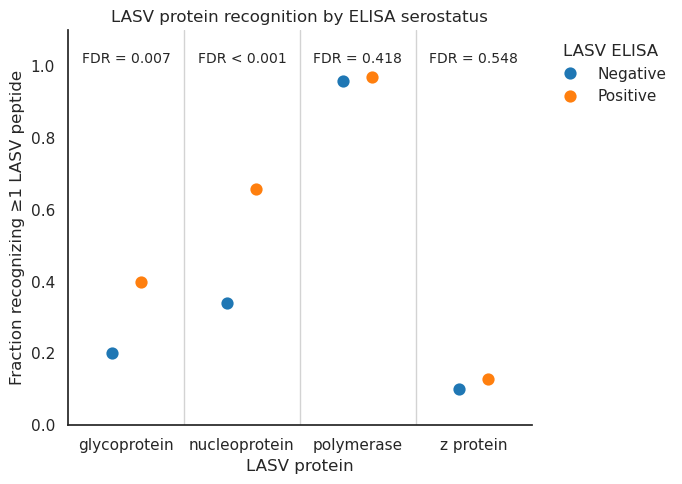

In [177]:
fig, ax = plt.subplots(figsize=(7, 5))

protein_order = [
    'glycoprotein',
    'nucleoprotein',
    'polymerase',
    'z protein'
]

sns.pointplot(
    data=protein_plot,
    x='protein_std',
    y='prevalence',
    hue='Serology_Result_Corrected',
    order=protein_order,
    dodge=0.25,
    linestyles='none',
    markers='o',
    ax=ax
)

# Vertical dividers
for x in [0.5, 1.5, 2.5]:
    ax.axvline(
        x=x,
        color='lightgray',
        linewidth=1,
        zorder=0
    )

ax.set_ylim(0, 1.1)

ax.set_xlabel(
    'LASV protein')

ax.set_ylabel(
    'Fraction recognizing ≥1 LASV peptide')

ax.set_title(
    'LASV protein recognition by ELISA serostatus')

ax.legend(
    title='LASV ELISA',
    frameon=False, 
    loc='upper left', 
    bbox_to_anchor=(1.02, 1))

p_values = {
    'glycoprotein': 0.006526,
    'nucleoprotein': 0.000002,
    'polymerase': 0.418318,
    'z protein': 0.547975}

for i, protein in enumerate(protein_order):

    p = p_values[protein]

    if p < 0.001:
        label = 'FDR < 0.001'
    else:
        label = f'FDR = {p:.3f}'

    ax.text(
        i,
        1.04,
        label,
        ha='center',
        va='top',
        fontsize=10)

sns.despine()

plt.tight_layout()
plt.show()

In [178]:
from scipy.stats import mannwhitneyu

neg = lasv_concordance.loc[
    lasv_concordance['Serology_Result_Corrected'] == 'Negative',
    'n_LASV_reactive_peptides'
]

pos = lasv_concordance.loc[
    lasv_concordance['Serology_Result_Corrected'] == 'Positive',
    'n_LASV_reactive_peptides'
]

mannwhitneyu(pos, neg, alternative='two-sided')

MannwhitneyuResult(statistic=np.float64(11624.0), pvalue=np.float64(9.698789032538046e-05))

In [179]:
lasv_concordance.columns

Index(['individual', 'cohort', 'sum_rpk', 'sum_zscore', 'log10_sum_rpk',
       'log2_sum_rpk', 'Sample', 'Classification', 'Sample_Date',
       'NP_Calc_Conc', 'NP_FINAL_RESULT', 'GP_Calc_Conc', 'GP_FINAL_RESULT',
       'Neut_Percent', 'Neut_Result ', 'Serology_Result_Corrected',
       'Sample_Date_parsed', 'Month_Year', 'PhIP-Seq_seropositive_1SD',
       'PhIP-Seq_seropositive_max', 'n_LASV_reactive_peptides',
       'LASV_seroreactive', 'LASV_median_reactive_z', 'LASV_max_reactive_z',
       'LASV_sum_reactive_z', 'LASV_num_np_reactive', 'LASV_np_seroreactive',
       'LASV_median_np_reactive_z', 'LASV_max_np_reactive_z',
       'LASV_sum_np_reactive_z', 'LASV_num_gp_reactive',
       'LASV_gp_seroreactive', 'LASV_median_gp_reactive_z',
       'LASV_max_gp_reactive_z', 'LASV_sum_gp_reactive_z', 'PhIP-Seq result'],
      dtype='object')

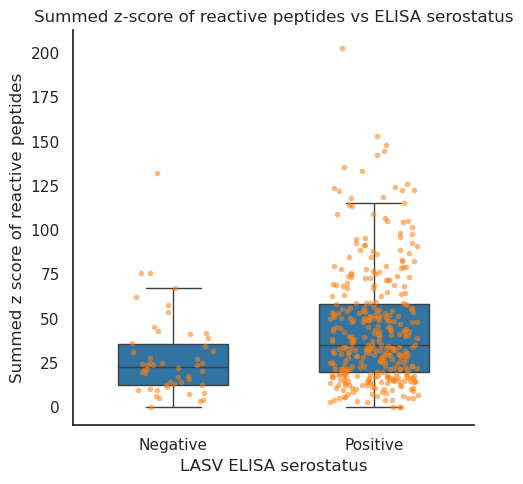

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(5, 5))

order = ['Negative', 'Positive']

sns.boxplot(
    data=lasv_concordance,
    x='Serology_Result_Corrected',
    y='LASV_sum_reactive_z',
    order=order,
    showfliers=False,
    width=0.55,
    ax=ax
)

sns.stripplot(
    data=lasv_concordance,
    x='Serology_Result_Corrected',
    y='LASV_sum_reactive_z',
    order=order,
    jitter=0.22,
    alpha=0.55,
    size=4,
    ax=ax
)

ax.set_xlabel('LASV ELISA serostatus')
ax.set_ylabel('Summed z score of reactive peptides')

ax.set_title('Summed z-score of reactive peptides vs ELISA serostatus')

sns.despine()
plt.tight_layout()
plt.show()

### are the peptides reactive in ELISA negative individuals the same as the ones in ELISA positive individuals? 

In [181]:
lasv_sero_neg = lasv_concordance.loc[lasv_concordance['Serology_Result_Corrected'] == 'Negative']['individual'].to_list()
lasv_sero_pos = lasv_concordance.loc[lasv_concordance['Serology_Result_Corrected'] == 'Positive']['individual'].to_list()

In [182]:
lasv_sero_neg_phip_pos = lasv.loc[(lasv['individual'].isin(lasv_sero_neg) )& (lasv['reactive'] == True)]

lasv_sero_neg_phip_neg = lasv.loc[(lasv['individual'].isin(lasv_sero_neg) )& (lasv['reactive'] == False)]

lasv_sero_pos_phip_pos = lasv.loc[(lasv['individual'].isin(lasv_sero_pos) )& (lasv['reactive'] == True)]

lasv_sero_pos_phip_neg = lasv.loc[(lasv['individual'].isin(lasv_sero_pos) )& (lasv['reactive'] == False)]

In [183]:
lasv_sero_neg_phip_pos.groupby('protein_std')['individual'].nunique()

protein_std
glycoprotein     10
nucleoprotein    17
polymerase       48
z protein         5
Name: individual, dtype: int64

In [184]:
lasv_sero_neg_phip_neg.groupby('protein_std')['individual'].nunique()

protein_std
glycoprotein     50
nucleoprotein    50
polymerase       50
z protein        50
Name: individual, dtype: int64

In [185]:
lasv_sero_pos_phip_pos.groupby('protein_std')['individual'].nunique()

protein_std
glycoprotein     138
nucleoprotein    228
polymerase       337
z protein         45
Name: individual, dtype: int64

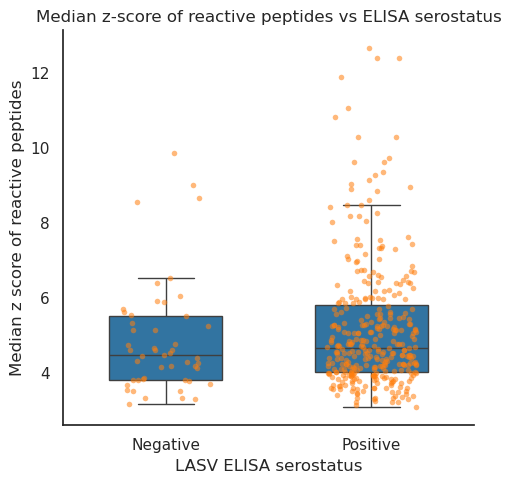

In [186]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(5, 5))

order = ['Negative', 'Positive']



sns.boxplot(
    data=lasv_concordance,
    x='Serology_Result_Corrected',
    y='LASV_median_reactive_z',
    order=order,
    showfliers=False,
    width=0.55,
    ax=ax
)

sns.stripplot(
    data=lasv_concordance,
    x='Serology_Result_Corrected',
    y='LASV_median_reactive_z',
    order=order,
    jitter=0.22,
    alpha=0.55,
    size=4,
    ax=ax
)

ax.set_xlabel('LASV ELISA serostatus')
ax.set_ylabel('Median z score of reactive peptides')

ax.set_title('Median z-score of reactive peptides vs ELISA serostatus')

sns.despine()
plt.tight_layout()
plt.show()

## confusion matrix

In [187]:
from sklearn.metrics import (
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    classification_report
)

cm = confusion_matrix(
    lasv_concordance['Serology_Result_Corrected'], lasv_concordance['PhIP-Seq_seropositive_1SD'], 
    labels=['Negative', 'Positive']
)

cm

array([[ 11,  39],
       [ 33, 314]])

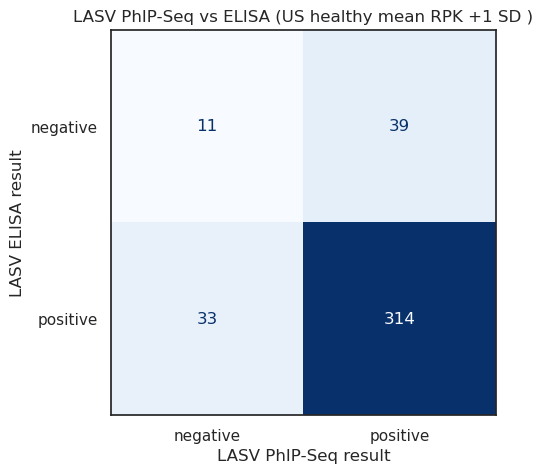

In [188]:
fig, ax = plt.subplots(
    figsize=(6, 5)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['negative', 'positive']
)

disp.plot(ax=ax, cmap='Blues', colorbar=False)

ax.set_ylabel('LASV ELISA result')
ax.set_xlabel('LASV PhIP-Seq result')
ax.set_title('LASV PhIP-Seq vs ELISA (US healthy mean RPK +1 SD )')

plt.show()

In [189]:
conditions = [(lasv_concordance['Serology_Result_Corrected'] == 'Positive') & (lasv_concordance['PhIP-Seq_seropositive_1SD'] == 'Positive'), 
              (lasv_concordance['Serology_Result_Corrected'] == 'Positive') & (lasv_concordance['PhIP-Seq_seropositive_1SD'] == 'Negative'), 
              (lasv_concordance['Serology_Result_Corrected'] == 'Negative') & (lasv_concordance['PhIP-Seq_seropositive_1SD'] == 'Positive'), 
              (lasv_concordance['Serology_Result_Corrected'] == 'Negative') & (lasv_concordance['PhIP-Seq_seropositive_1SD'] == 'Negative')
]

In [190]:
choices = ['True pos', 'Fals neg', 'False pos', 'True neg']

lasv_concordance['concordance'] = np.select(conditions, choices, default='Unknown')

In [191]:
fp_individuals = (
    lasv_concordance.loc[
        lasv_concordance['concordance'] == 'False pos',
        'individual'
    ]
    .tolist()
)

print(
    'Number of discordant individuals:',
    len(fp_individuals)
)

Number of discordant individuals: 39


In [192]:
fp_lasv_hits = (
    lasv[
        lasv['individual'].isin(fp_individuals)
        &
        lasv['reactive']
    ]
    .copy()
)

In [193]:
lasv_concordance['PhIP_LASV_status'] = np.where(lasv_concordance['LASV_seroreactive'], 'Positive', 'Negative')

In [194]:
from sklearn.metrics import (
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    classification_report
)

cm = confusion_matrix(
    lasv_concordance['Serology_Result_Corrected'], lasv_concordance['PhIP_LASV_status'], 
    labels=['Negative', 'Positive']
)

cm

array([[  1,  49],
       [  3, 344]])

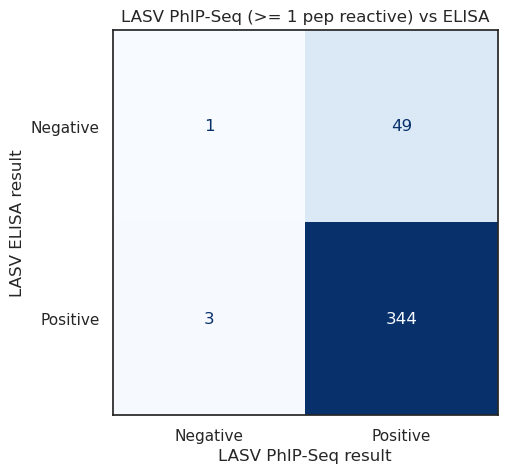

In [195]:
fig, ax = plt.subplots(
    figsize=(6, 5)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Negative', 'Positive']
)

disp.plot(ax=ax, cmap='Blues', colorbar=False)

ax.set_ylabel('LASV ELISA result')
ax.set_xlabel('LASV PhIP-Seq result')
ax.set_title('LASV PhIP-Seq (>= 1 pep reactive) vs ELISA')

plt.show()

In [196]:
lasv_concordance['PhIP_LASV_status'].count()

np.int64(397)

### now address cross-reactivity issue

# What explains the co-recognition? Starting with Mammarenavirus genus first

**Question** does sequence similairy predict co-recognition? And are those recognized by the same individuals more frequently than sequence-dissimilar cross-species peptides?

For every pair of peptides from different species within the same genus, calculate the 

i) sequence similarity
ii) people recognizing peptide A
iii) people recognizing peptide B
iv) people recognizing both
v) co-recognition score )(Jaccard similarity)

In [197]:
peptide_individual = (
    long.groupby(['peptide', 'individual'], observed=True)['reactive'].any().unstack()
)

In [198]:
peps_metadata = peps_metadata.set_index('peptide')
long = long.set_index('peptide')

KeyError: "None of ['peptide'] are in the columns"

In [ ]:
#peptide metadata
mamma_peps = peps_metadata[peps_metadata['genus'] == 'Mammarenavirus'].index
mamma_matrix = (peptide_individual.loc[peptide_individual.index.isin(mamma_peps)])

#subset to SL only
prefixes = ('S', 'C')
mamma_matrix = mamma_matrix.loc[:, mamma_matrix.columns.str.startswith(prefixes)]


In [ ]:
#caluclate peptide prevalence
peptide_prevalence = (
    mamma_matrix
    .mean(axis=1)
    .rename('peptide_prevalence')
)

In [ ]:
#calculating pairwise co-recognition 
X = (
    mamma_matrix.astype(int) #converting True False to 0 and 1
)

co_recognition_matrix = (X @ X.T)


In [ ]:
peptides = co_recognition_matrix.index.to_list()
rows = []

for i in range(len(peptides)):
    for j in range(i + 1, len(peptides)): #avoids self pairing.
        rows.append({
            'peptide_a': peptides[i], 
            'peptide_b': peptides[j], 
            'n_co_recognizing': 
                co_recognition_matrix.iloc[i, j]
        })

co_pairs = pd.DataFrame(rows)

In [ ]:
# add metadata to co_pairs

co_pairs = co_pairs.merge(
    peps_metadata[['species', 'genus', 'family', 'protein_std']].add_suffix('_a'), 
                          left_on='peptide_a', right_index=True, how='left' #trying to merge on peptide_a and the peps_metadata index, both actual strings
                          )

co_pairs = co_pairs.merge(
    peps_metadata[['species', 'genus', 'family', 'protein_std']].add_suffix('_b'), 
                          left_on='peptide_b', right_index=True, how='left' #trying to merge on peptide_a and the peps_metadata index, both actual strings
                          )

In [ ]:
# now do cross-recognition analysis. first festrict co-pairs to peptides from different viral species within Mammarenavirus genus
# excluding same mammarenavirus species

mamma_cross_species_pairs = (
    co_pairs[co_pairs['species_a'] != co_pairs['species_b']]
    .copy()
)

mamma_co_pairs = (
    co_pairs[co_pairs['species_a'] == co_pairs['species_b']].copy()
)


In [ ]:
mamma_peptide_prevalence = (
    mamma_matrix.mean(axis=1).rename('mamma_peptide_prevalence')
)

mamma_cross_species_pairs['prevalence_a'] = (
    mamma_cross_species_pairs['peptide_a'].map(mamma_peptide_prevalence)
)

mamma_cross_species_pairs['prevalence_b'] = (
    mamma_cross_species_pairs['peptide_b'].map(mamma_peptide_prevalence)
)

In [ ]:
# Jaccard Co-recognition

n_individuals = mamma_matrix.shape[1]

mamma_cross_species_pairs['n_a'] = (
    mamma_cross_species_pairs['prevalence_a'] * n_individuals
)

mamma_cross_species_pairs['n_b'] = (
    mamma_cross_species_pairs['prevalence_b'] * n_individuals
)

In [ ]:
#add jaccard analysis

mamma_cross_species_pairs['jaccard'] = (
    mamma_cross_species_pairs['n_co_recognizing']
    /
    (mamma_cross_species_pairs['n_a']
     + 
     mamma_cross_species_pairs['n_b']
     - 
     mamma_cross_species_pairs['n_co_recognizing']
     )
)

## run the sequence-linked peptide network block and come back to run this section now. Will find peptides that have a shared 7-aa stretch and call them linked

In [ ]:
sequence_linked_pairs = []

for peptide_a, peptide_b, attrs in G_seq.edges(data=True):

    sequence_linked_pairs.append({
        'peptide_a': peptide_a, 
        'peptide_b': peptide_b,
        'shared_kmers': attrs['shared_kmers'], 
        'n_shared_kmers': len(attrs['shared_kmers']) #how many distinct exact 7-aa do the peptides have in common
        #could be useful when exploring dose response -> if peptides sharing more 7-mers have greater co-recognition

    })

sequence_linked_pairs = pd.DataFrame(
    sequence_linked_pairs
)

NameError: name 'G_seq' is not defined

In [ ]:
# create an unordered pair key A-B and B-A are same peptide pair. 

def make_pair_key(a, b):
    return tuple(
        sorted(
            [str(a), str(b)]
        )
    )

sequence_linked_pairs['pair_key'] = [
    make_pair_key(a, b)
    for a, b in zip(sequence_linked_pairs['peptide_a'], # zip loops through multple lists or other iterables locking into pairs
    sequence_linked_pairs['peptide_b']
    )
]


In [ ]:
# connect to the mamma cross species dataframe 

linked_pair_keys = set(sequence_linked_pairs['pair_key'])

mamma_cross_species_pairs['pair_key'] = [make_pair_key(a, b)
    for a, b in zip(mamma_cross_species_pairs['peptide_a'],mamma_cross_species_pairs['peptide_b'])]

mamma_cross_species_pairs['sequence_linked'] = (mamma_cross_species_pairs['pair_key'] #asks is the pair_key is in linked_pair_key
    .isin(linked_pair_keys))

In [ ]:
mamma_cross_species_pairs['sequence_linked'].value_counts()

sequence_linked
False    22858
True       221
Name: count, dtype: int64

In [ ]:
mamma_cross_species_pairs = (
    mamma_cross_species_pairs
    .merge(
        sequence_linked_pairs[
            ['pair_key','shared_kmers','n_shared_kmers']],on='pair_key',how='left')
)

mamma_cross_species_pairs['n_shared_kmers'] = (mamma_cross_species_pairs['n_shared_kmers'].fillna(0).astype(int))

In [ ]:
sequence_summary = (
    mamma_cross_species_pairs
    .groupby(
        'sequence_linked'
    )
    .agg(
        n_pairs=('jaccard', 'size'),
        median_jaccard=('jaccard','median'),
        mean_jaccard=('jaccard','mean'),
        median_n_co_recognizing=('n_co_recognizing','median'),
        median_prevalence_a=('prevalence_a','median'),
        median_prevalence_b=('prevalence_b','median')
    )
    .reset_index()
)
display(sequence_summary
)

,sequence_linked,n_pairs,median_jaccard,mean_jaccard,median_n_co_recognizing,median_prevalence_a,median_prevalence_b
0,False,22858,0.042553,0.046629,3.0,0.070529,0.073048
1,True,221,0.090909,0.148186,6.0,0.073048,0.073048


/tmp/ipykernel_1140854/2235105574.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


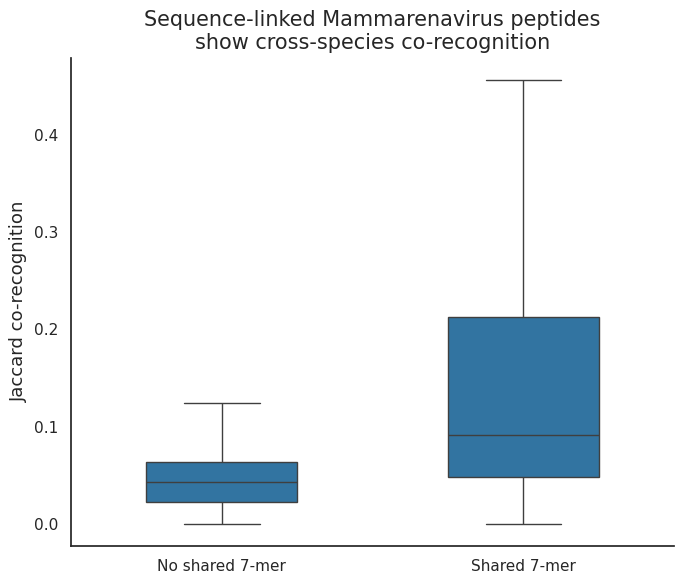

In [ ]:
fig, ax = plt.subplots(
    figsize=(7, 6)
)

sns.boxplot(
    data=mamma_cross_species_pairs,x='sequence_linked',y='jaccard',
    showfliers=False,
    width=0.5,

    ax=ax)

ax.set_xticklabels(
    ['No shared 7-mer', 'Shared 7-mer']
)

ax.set_xlabel('')

ax.set_ylabel(
    'Jaccard co-recognition',
    fontsize=13
)

ax.set_title(
    'Sequence-linked Mammarenavirus peptides\n'
    'show cross-species co-recognition',
    fontsize=15
)

sns.despine(
    ax=ax)

plt.tight_layout()

plt.show()

In [ ]:
shared_kmer_summary = (
    mamma_cross_species_pairs
    .groupby('n_shared_kmers')
    .agg(
        n_pairs=('jaccard', 'size'),
        median_jaccard=('jaccard', 'median'),
        mean_jaccard=('jaccard', 'mean')
    )
    .reset_index()
)

display(shared_kmer_summary)

,n_shared_kmers,n_pairs,median_jaccard,mean_jaccard
0,0,22858,0.042553,0.046629
1,1,44,0.045478,0.054877
2,2,38,0.100787,0.143057
3,3,18,0.099296,0.137559
4,4,23,0.090909,0.189832
5,5,27,0.180000,0.203988
6,6,14,0.225000,0.242576
7,7,11,0.114286,0.123887
8,8,7,0.096154,0.190514
9,9,9,0.067164,0.144216


In [ ]:
mamma_cross_species_pairs['same_protein'] = (
    mamma_cross_species_pairs['protein_std_a']
    ==
    mamma_cross_species_pairs['protein_std_b']
)

same_protein_pairs = (
    mamma_cross_species_pairs[
        mamma_cross_species_pairs['same_protein']
    ]
    .copy()
)

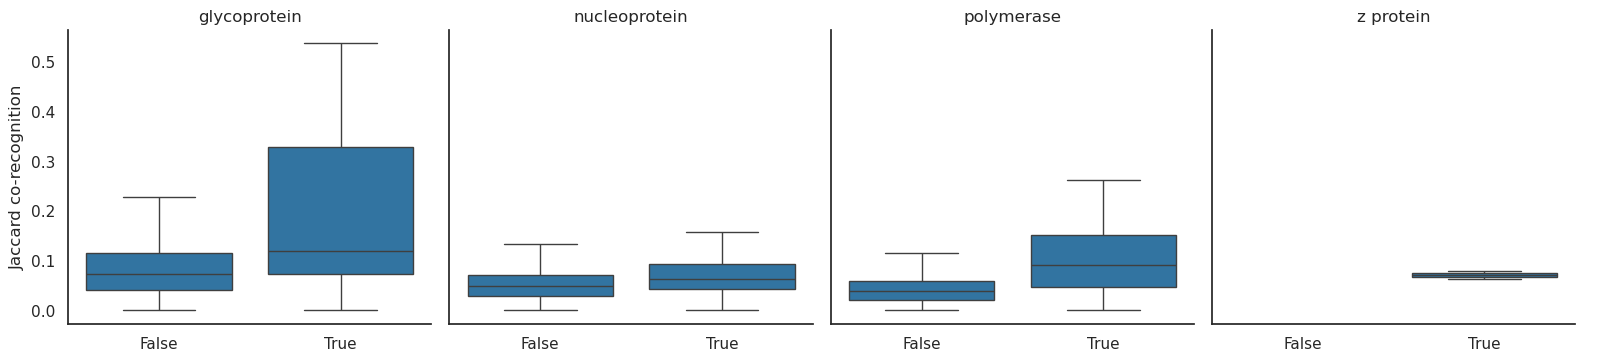

In [ ]:
g = sns.catplot(
    data=same_protein_pairs,
    x='sequence_linked',
    y='jaccard',
    col='protein_std_a',
    kind='box',
    showfliers=False,
    col_wrap=4,
    height=4
)

g.set_axis_labels(
    '',
    'Jaccard co-recognition'
)

g.set_titles(
    '{col_name}'
)

plt.show()

In [ ]:
protein_summary = (
    same_protein_pairs
    .groupby(
        [
            'protein_std_a','sequence_linked'
        ],
        observed=True
    )
    .agg(
        n_pairs=('jaccard','size'
        ), median_jaccard=('jaccard','median'),

        mean_jaccard=('jaccard','mean'
        ),
        median_prevalence_a=('prevalence_a','median'
        ),
        median_prevalence_b=('prevalence_b','median'
        )
    )
    .reset_index()
)
display(protein_summary)

,protein_std_a,sequence_linked,n_pairs,median_jaccard,mean_jaccard,median_prevalence_a,median_prevalence_b
0,glycoprotein,False,248,0.072621,0.096484,0.088161,0.073048
1,glycoprotein,True,80,0.120530,0.199228,0.103275,0.073048
2,nucleoprotein,False,906,0.050000,0.055623,0.098237,0.100756
3,nucleoprotein,True,65,0.062992,0.091862,0.098237,0.098237
4,polymerase,False,9699,0.038462,0.042183,0.068010,0.060453
5,polymerase,True,63,0.090909,0.124295,0.062972,0.055416
6,z protein,True,2,0.071023,0.071023,0.065491,0.161209


# Figure 4 — Sequence-linked peptide networks

**Question:** Could multi-species seroreactivity reflect shared sequence features among viral peptide targets?

The network is built from **all filtered peptides**, not only those displayed in the heatmap. Two peptides are connected when they share an exact 8-amino-acid k-mer; connected components define sequence-linked peptide clusters.

We then select two biologically targeted examples, while first focusing on the **Mammarenavirus genus** as a follow up study to the heatmap, where cross-species reactivity was observed. 


Node color = species; node shape = standardized protein class; node size = fraction of SL individuals with z>3 for that peptide. Peptide labels are deliberately omitted for readability.

In [ ]:

# FIGURE 4: BUILD ALL-PEPTIDE 7-MER NETWORK -

K = 7

def get_kmers(sequence, k=K):
    sequence = str(sequence).upper()
    if len(sequence) < k:
        return set()
    return {
        sequence[i:i+k]
        for i in range(len(sequence) - k + 1)
    }


# Map k-mer -> peptides
# this creates an empty dictionary where the key will be the 7-mer, and the values the peptides containing it
kmer_to_peptides = defaultdict(list)

for peptide, sequence in (
    #itertuples allows you to loop through rows of a dataframe which columns defined, returning a tuple
    hits[['peptide', 'sequence']].itertuples(index=False)
):
    for kmer in get_kmers(sequence):
        kmer_to_peptides[kmer].append(peptide)

# Build graph
G_seq = nx.Graph()

for _, row in hits.iterrows():
    G_seq.add_node(
        row['peptide'],
        sequence=row['sequence'],
        species=row['species'],
        genus=row['genus'],
        family=row['family'],
        protein_name=row['protein_std'], #here protein_std will be named protein_name in the connected graph
        sl_prevalence=row['sensitivity']
    )

for kmer, peptides in kmer_to_peptides.items():
    peptides = list(set(peptides))
    if len(peptides) < 2: #need to have at least 2 peptides mapping to a kmer to form an edge
        continue
    for p1, p2 in combinations(peptides, 2):
        if G_seq.has_edge(p1, p2):
            G_seq[p1][p2]['shared_kmers'].append(kmer)
        else:
            G_seq.add_edge(
                p1,
                p2,
                shared_kmers=[kmer]
            )

components_seq = list(
    nx.connected_components(G_seq)
)

print(f'Peptide nodes: {G_seq.number_of_nodes()}')
print(f'Edges: {G_seq.number_of_edges()}')
print(f'Connected components: {len(components_seq)}')

Peptide nodes: 1274
Edges: 1135
Connected components: 804


In [ ]:
# SELECT TARGET-CONTAINING CLUSTERS

TARGET_LASSA = 'Mammarenavirus lassaense'

def summarize_components(components, network_hits):
    records = []

    for cluster_id, component in enumerate(components):
        sub = network_hits[
            network_hits['peptide'].isin(component)
        ]
        species = sorted( #append species to peptide in cluster
            sub['species'].dropna().unique().tolist()
        )
        genera = sorted( #appendd genus
            sub['genus'].dropna().unique().tolist()
        )
        families = sorted(
            sub['family'].dropna().unique().tolist()
        )
        proteins = sorted(
            sub['protein_std'].dropna().unique().tolist()
        )

        records.append({
            'cluster_id': cluster_id,
            'n_peptides': sub['peptide'].nunique(),
            'n_species': len(species),
            'n_genera': len(genera),
            'n_families': len(families),
            'species': species,
            'genera': genera,
            'families': families,
            'proteins': proteins
        })

    return pd.DataFrame(records)

cluster_summary = summarize_components(
    components_seq,
    hits
)

def select_target_cluster( #find clusters that contain the target species, 
    #contain at least two species but where all species belong to the target genus
    target_species,
    target_genus
):
    candidates = cluster_summary[
        cluster_summary['species'].apply(
            #does the cluster have the target species you are interested in?
            lambda x: target_species in x
        )
        &
        cluster_summary['genera'].apply(
            #asks if that cluster contains exactly one genus and if it is the target_genus
            lambda x: len(x) == 1 and x[0] == target_genus
        )
        &
        (cluster_summary['n_species'] >= 2)
    ].copy()

    if candidates.empty:
        return None, candidates

    candidates = (
        candidates
        .sort_values(
            ['n_species', 'n_peptides'], #highest number of species wins, then n_peptides comes second as criterion
            ascending=False
        )
        .reset_index(drop=True) #renumbers sorted rows with 0, 1, 2.. etc.
    )

    return candidates.iloc[0], candidates


mamma_selected, mamma_candidates = select_target_cluster(
    TARGET_LASSA,
    'Mammarenavirus'
)

if mamma_selected is None:
    raise ValueError(
        f'No cross-species Mammarenavirus cluster contains {TARGET_LASSA}.'
    )

print('Selected Mammarenavirus cluster:')
display(mamma_selected.to_frame().T)

print('Other qualifying Mammarenavirus clusters:')
display(mamma_candidates.head(30))


Selected Mammarenavirus cluster:


,cluster_id,n_peptides,n_species,n_genera,n_families,species,genera,families,proteins
0,2,14,8,1,1,"[Mammarenavirus bearense, Mammarenavirus calie...",[Mammarenavirus],[Arenaviridae],[glycoprotein]


Other qualifying Mammarenavirus clusters:


,cluster_id,n_peptides,n_species,n_genera,n_families,species,genera,families,proteins
0,2,14,8,1,1,"[Mammarenavirus bearense, Mammarenavirus calie...",[Mammarenavirus],[Arenaviridae],[glycoprotein]
1,158,9,5,1,1,"[Mammarenavirus amapariense, Mammarenavirus ca...",[Mammarenavirus],[Arenaviridae],[polymerase]
2,8,8,5,1,1,"[Mammarenavirus kwanzaense, Mammarenavirus las...",[Mammarenavirus],[Arenaviridae],[polymerase]
3,126,3,3,1,1,"[Mammarenavirus kwanzaense, Mammarenavirus las...",[Mammarenavirus],[Arenaviridae],[polymerase]
4,82,6,2,1,1,"[Mammarenavirus lassaense, Mammarenavirus wenz...",[Mammarenavirus],[Arenaviridae],[polymerase]
5,160,3,2,1,1,"[Mammarenavirus lassaense, Mammarenavirus mafi...",[Mammarenavirus],[Arenaviridae],[z protein]
6,68,2,2,1,1,"[Mammarenavirus lassaense, Mammarenavirus tami...",[Mammarenavirus],[Arenaviridae],[polymerase]


In [ ]:
mamma_gp_candidates = (
    mamma_candidates[mamma_candidates['proteins'].apply(
        lambda x: 'glycoprotein' in x
    )]
    .copy()
)

mamma_pol_clusters = (
    mamma_candidates[mamma_candidates['proteins'].apply(
        lambda x: 'polymerase'in x
                     )].copy()
)

In [ ]:
gp_cluster_ids = (mamma_gp_candidates['cluster_id'].to_list())

gp_peptides = []

for cluster_id in gp_cluster_ids:
    component = (
        components_seq[cluster_id]
    )

    sub = hits[hits['peptide'].isin(component)]

    sub['cluster_id'] = cluster_id

    gp_peptides.append(sub)

gp_peptides= pd.concat(gp_peptides, ignore_index=True)

/tmp/ipykernel_1140854/1949109939.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub['cluster_id'] = cluster_id


In [ ]:
pol_cluster_ids = (mamma_pol_clusters['cluster_id'].to_list())

pol_peptides = []

for cluster_id in pol_cluster_ids:
    component = (
        components_seq[cluster_id]
    )

    sub = hits[hits['peptide'].isin(component)]

    sub['cluster_id'] = cluster_id

    pol_peptides.append(sub)

pol_peptides = pd.concat(pol_peptides, ignore_index=True)

/tmp/ipykernel_1140854/3371893982.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub['cluster_id'] = cluster_id
/tmp/ipykernel_1140854/3371893982.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub['cluster_id'] = cluster_id
/tmp/ipykernel_1140854/3371893982.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

## which ones are the peptides with high sensitivity and truly only found in Mammarenavirus lassaense without falling into a cross-species within genus bucket? 

In [ ]:
# SELECT TARGET-CONTAINING CLUSTERS

TARGET_LASSA = 'Mammarenavirus lassaense'

def select_target_cluster_one_species( #find clusters that contain ONLY the target species, 
    #contain ONLY one species but where all species belong to the target genus
    target_species,
    target_genus
):
    candidates = cluster_summary[
        cluster_summary['species'].apply(
            #does the cluster have the target species you are interested in?
            lambda x: target_species in x
        )
        &
        cluster_summary['genera'].apply(
            #asks if that cluster contains exactly one genus and if it is the target_genus
            lambda x: len(x) == 1 and x[0] == target_genus
        )
        &
        (cluster_summary['n_species'] == 1)
    ].copy()

    if candidates.empty:
        return None, candidates

    candidates = (
        candidates
        .sort_values(
            ['n_species', 'n_peptides'], #highest number of species wins, then n_peptides comes second as criterion
            ascending=False
        )
        .reset_index(drop=True) #renumbers sorted rows with 0, 1, 2.. etc.
    )

    return candidates.iloc[0], candidates


mamma_selected, mamma_candidates = select_target_cluster_one_species(
    TARGET_LASSA,
    'Mammarenavirus'
)

if mamma_selected is None:
    raise ValueError(
        f'No cross-species Mammarenavirus cluster contains {TARGET_LASSA}.'
    )

print('Selected Mammarenavirus cluster:')
display(mamma_selected.to_frame().T)

print('Other qualifying Mammarenavirus clusters:')
display(mamma_candidates.head(30))


Selected Mammarenavirus cluster:


,cluster_id,n_peptides,n_species,n_genera,n_families,species,genera,families,proteins
0,80,17,1,1,1,[Mammarenavirus lassaense],[Mammarenavirus],[Arenaviridae],[polymerase]


Other qualifying Mammarenavirus clusters:


,cluster_id,n_peptides,n_species,n_genera,n_families,species,genera,families,proteins
0,80,17,1,1,1,[Mammarenavirus lassaense],[Mammarenavirus],[Arenaviridae],[polymerase]
1,157,9,1,1,1,[Mammarenavirus lassaense],[Mammarenavirus],[Arenaviridae],[polymerase]
2,67,6,1,1,1,[Mammarenavirus lassaense],[Mammarenavirus],[Arenaviridae],[polymerase]
3,81,6,1,1,1,[Mammarenavirus lassaense],[Mammarenavirus],[Arenaviridae],[polymerase]
4,133,2,1,1,1,[Mammarenavirus lassaense],[Mammarenavirus],[Arenaviridae],[polymerase]
5,69,1,1,1,1,[Mammarenavirus lassaense],[Mammarenavirus],[Arenaviridae],[polymerase]
6,109,1,1,1,1,[Mammarenavirus lassaense],[Mammarenavirus],[Arenaviridae],[glycoprotein]
7,110,1,1,1,1,[Mammarenavirus lassaense],[Mammarenavirus],[Arenaviridae],[polymerase]
8,111,1,1,1,1,[Mammarenavirus lassaense],[Mammarenavirus],[Arenaviridae],[polymerase]
9,159,1,1,1,1,[Mammarenavirus lassaense],[Mammarenavirus],[Arenaviridae],[polymerase]


In [ ]:
mamma_candidates = mamma_candidates[mamma_candidates['proteins'].apply(lambda x: 'glycoprotein' in x)] .copy() 

gp_cluster_ids = (mamma_candidates['cluster_id'].to_list())

gp_peptides = []

for cluster_id in gp_cluster_ids:
    component = (
        components_seq[cluster_id]
    )

    sub = hits[hits['peptide'].isin(component)]

    sub['cluster_id'] = cluster_id

    gp_peptides.append(sub)

gp_peptides= pd.concat(gp_peptides, ignore_index=True)

/tmp/ipykernel_1140854/4160460325.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub['cluster_id'] = cluster_id


In [ ]:
gp_peptides

,peptide,sensitivity,specificity,sequence,accession,protein_name,gene,segment,order,family,...,species,isolate,taxonomy_lineage,collection_date,geo_loc_name,host,protein_std,fragment,collection_date_standardized,cluster_id
0,ANH09740.1|precursor|Mammarenavirus_lassaense|...,0.088161,1.0,FHLSIPNFNQYEAMSCDFNGGKISIQYNLSHSYAGDAAQHCGTVAN,ANH09740.1,glycoprotein precursor,GPC,NaN,Hareavirales,Arenaviridae,...,Mammarenavirus lassaense,NaN,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,15-Mar-12,Nigeria,Hylomyscus pamfi,glycoprotein,7,3/15/12,109


In [ ]:
gp_pep = long.loc[gp_peptides['peptide']]

gp_mean = gp_pep.groupby('category')['reactive'].mean()

gp_mean

category
Household contact    0.090253
Lassa survivor       0.083333
US healthy           0.000000
Name: reactive, dtype: float64

### does this pep correlate with serostatus

In [ ]:
lasv_elisa_data

,individual,cohort,sum_rpk,sum_zscore,log10_sum_rpk,log2_sum_rpk,Sample,Classification,Sample_Date,NP_Calc_Conc,NP_FINAL_RESULT,GP_Calc_Conc,GP_FINAL_RESULT,Neut_Percent,Neut_Result,Serology_Result_Corrected,Sample_Date_parsed,Month_Year,PhIP-Seq_seropositive_1SD,PhIP-Seq_seropositive_max
species,,,,,,,,,,,,,,,,,,,,
Mammarenavirus lassaense,C-109-1_5_B3,SL,267.784634,94.993317,2.429404,8.070307,C-109-1,Contact,1-Dec-20,1,Negative,1.835048,Negative,0.000000,Non-Neutralizing,Negative,2020-12-01,2020-12,Positive,Positive
Mammarenavirus lassaense,C-109-2_5_B5,SL,62.413638,-17.421378,1.802183,5.986721,C-109-2,Contact,2-Dec-20,1,Negative,1.972705,Negative,3.590000,Non-Neutralizing,Negative,2020-12-02,2020-12,Negative,Negative
Mammarenavirus lassaense,C-109-3_4_E7,SL,493.730175,54.794906,2.694368,8.950498,C-109-3,Contact,2-Dec-20,7.811206476,Positive,23.858109,Positive,83.771946,Strong,Positive,2020-12-02,2020-12,Positive,Positive
Mammarenavirus lassaense,C-110-1_2_A5,SL,72.565455,5.319490,1.866674,6.200957,C-110-1,Contact,10-Dec-18,2.218305288,Positive,2.629727,Negative,68.962085,Moderate,Positive,2018-12-10,2018-12,Negative,Negative
Mammarenavirus lassaense,C-110-2_3_F8,SL,92.961008,-37.408103,1.972948,6.553990,C-110-2,Contact,10-Dec-18,9.444842587,Positive,3.588056,Positive,49.083657,Non-Neutralizing,Positive,2018-12-10,2018-12,Positive,Negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Mammarenavirus lassaense,S-510_SA3_D5,SL,1485.388516,49.023206,3.172132,10.537596,S-510,Survivor,2-Dec-20,54.38258547,Positive,12.937340,Positive,84.984398,Strong,Positive,2020-12-02,2020-12,Positive,Positive
Mammarenavirus lassaense,S-511_SA5_A6,SL,121.886354,35.337907,2.089504,6.941181,S-511,Survivor,22-Mar,1,Negative,4.852416,Positive,0.000000,Non-Neutralizing,Positive,2022-03-01,2022-03,Positive,Positive
Mammarenavirus lassaense,S-512_SA3_G9,SL,219.494917,48.269860,2.343399,7.784602,S-512,Survivor,2-Dec-20,17.27870657,Positive,6.402496,Positive,83.696755,Strong,Positive,2020-12-02,2020-12,Positive,Positive


In [ ]:
mamma_pol = mamma_candidates.iloc[1]

In [ ]:
mamma_gly_np = mamma_candidates.iloc[5]

In [ ]:

# INSPECT THE PEPTIDE CONTENT OF THE SELECTED CLUSTERS

def inspect_cluster(cluster_row):
    component = components_seq[
        int(cluster_row['cluster_id'])
    ]

    return (
        hits[
            hits['peptide'].isin(component)
        ]
        [
            [
                'peptide',
                'sequence',
                'species',
                'genus',
                'family',
                'protein_std',
                'sensitivity'
            ]
        ]
        .sort_values(
            ['species', 'protein_std', 'peptide']
        )
        .reset_index(drop=True)
    )

mamma_data_gp = inspect_cluster(mamma_selected)
mamma_data_pol = inspect_cluster(mamma_pol)
mamma_gly_np = inspect_cluster(mamma_gly_np)

print('Mammarenavirus selected cluster')
display(mamma_data_gp)
display(mamma_data_pol)

NameError: name 'mamma_pol' is not defined

(0.596078431372549, 0.8745098039215686, 0.5411764705882353)
(0.596078431372549, 0.8745098039215686, 0.5411764705882353)


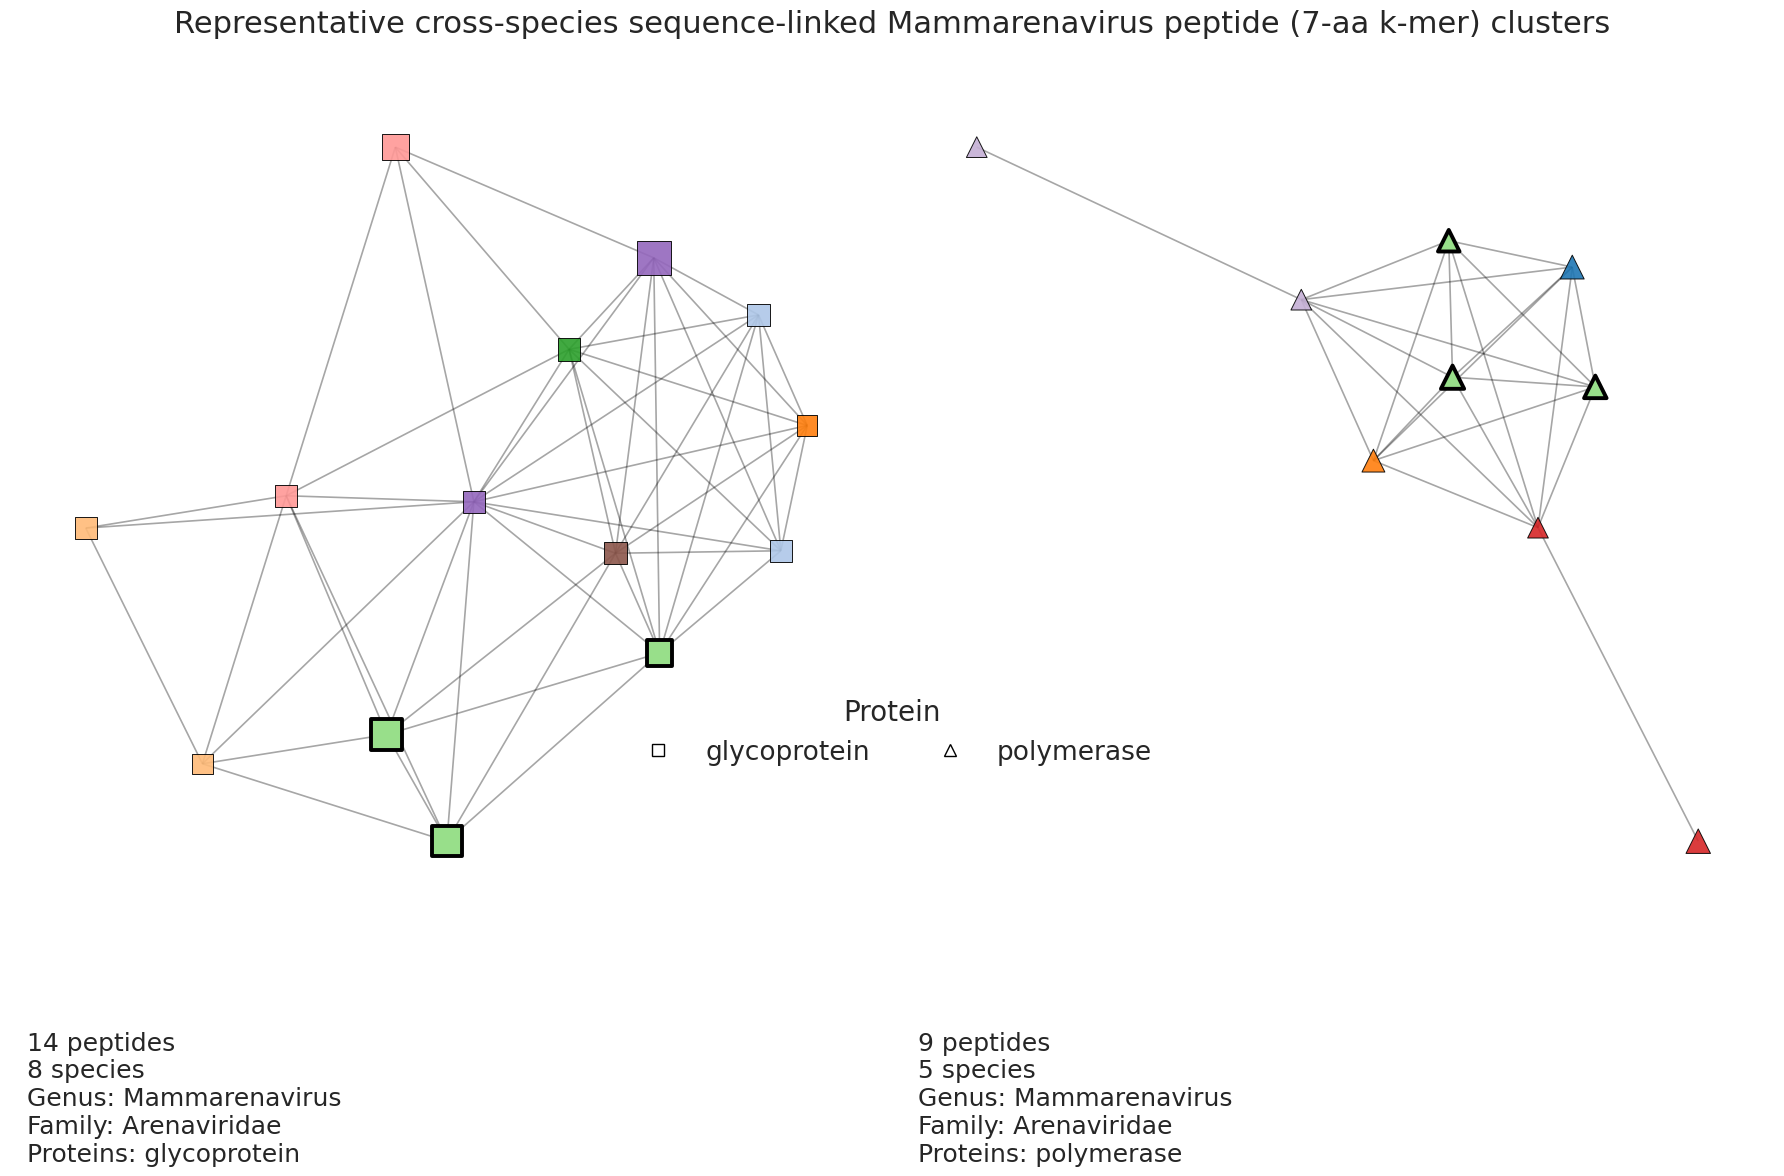

In [ ]:

# FIGURE 4 PLOT

protein_markers = {
   #'nucleoprotein': 'o',
    'glycoprotein': 's',
    'polymerase': '^',
   # 'matrix': 'D',
   # 'phosphoprotein': 'P',
   # 'nonstructural protein': 'v',
   # 'accessory protein': '<',
   # 'Other/Ambiguous': 'X'
}


def plot_cluster_network(ax, cluster_row, target_species, title):

    cluster_id = int(cluster_row['cluster_id'])
    component = components_seq[cluster_id]

    G = G_seq.subgraph(component).copy()

    G1_temp = G_seq.subgraph(
        components_seq[int(mamma_selected['cluster_id'])]
    )

    G2_temp = G_seq.subgraph(
    components_seq[int(mamma_pol['cluster_id'])]
)

    all_species = sorted(
        {
            G1_temp.nodes[node]['species']
            for node in G1_temp.nodes()
        }
        |
        {
            G2_temp.nodes[node]['species']
            for node in G2_temp.nodes()
        }
    )

    # One fixed color for each species across the entire figure
    tab20_colors = plt.cm.tab20.colors

    species_palette = {
        species: tab20_colors[i % 20]
        for i, species in enumerate(all_species)
    }

    visible_nodes = [
    node
    for node in G.nodes()
    if G.nodes[node]['protein_name'] in protein_markers
    ]

    species_here = sorted({
    G.nodes[node]['species']
    for node in visible_nodes
    })

    proteins_here = sorted({
        G.nodes[node]['protein_name']
        for node in visible_nodes
    })

    pos = nx.spring_layout( #nx.spring_layout() calculates where to place nodes when drawing a network
        G,
        seed=42,
        k=1.3,
        iterations=500
    )

    
    print(species_palette['Mammarenavirus lassaense'])

    # Edges
    nx.draw_networkx_edges( #draws edges
        G,
        pos,
        ax=ax,
        width=1.2,
        alpha=0.35
    )

    # Nodes: color = species, shape = standardized protein class
    for protein_type, marker in protein_markers.items():

        nodes = [
            node
            for node in G.nodes()
            if G.nodes[node]['protein_name'] == protein_type
        ]

        if not nodes:
            continue

        nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax,
            nodelist=nodes,
            node_size=[
                100 + 2200 * G.nodes[node]['sl_prevalence']
                for node in nodes
            ],
            node_color=[
                species_palette[G.nodes[node]['species']]
                for node in nodes
            ],
            node_shape=marker,
            edgecolors='black',
            linewidths=0.7,
            alpha=0.9
        )

    # Re-outline target species nodes WITHOUT changing their protein shapes
    for protein_type, marker in protein_markers.items():

        target_nodes = [
            node
            for node in G.nodes()
            if (
                G.nodes[node]['species'] == target_species
                and G.nodes[node]['protein_name'] == protein_type
            )
        ]

        if not target_nodes:
            continue

        nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax,
            nodelist=target_nodes,
            node_size=[
                130 + 2200 * G.nodes[node]['sl_prevalence']
                for node in target_nodes
            ],
            node_color=[
                species_palette[G.nodes[node]['species']]
                for node in target_nodes
            ],
            node_shape=marker,
            edgecolors='black',
            linewidths=2.8,
            alpha=1
        )

    # Metadata
    genera_here = sorted({
        G.nodes[node]['genus']
        for node in G.nodes()
    })

    families_here = sorted({
        G.nodes[node]['family']
        for node in G.nodes()
    })

    proteins_here = sorted({
        G.nodes[node]['protein_name']
        for node in G.nodes()
    })

    ax.text(
        0.02,
        -0.3,
        (
            f'{G.number_of_nodes()} peptides\n'
            f'{len(species_here)} species\n'
            f'Genus: {", ".join(genera_here)}\n'
            f'Family: {", ".join(families_here)}\n'
            f'Proteins: {", ".join(proteins_here)}'
        ),
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=18,
        bbox=dict(
            boxstyle='round,pad=0.4',
            facecolor='white',
            alpha=0.9,
            edgecolor='none'
        )
    )

    """ #uncomment if you want to set a title above each graph
    ax.set_title(
        title,
        fontsize=15,
        pad=15

    )"""

    ax.axis('off')

    return species_palette


fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 12)
)

mamma_palette = plot_cluster_network(
    axes[0],
    mamma_selected,
    TARGET_LASSA,
    'A  Mammarenavirus cluster containing Mammarenavirus lassaense'
)



mamma_palette = plot_cluster_network(
    axes[1],
    mamma_pol,
    TARGET_LASSA,
    'A  Mammarenavirus cluster containing Mammarenavirus lassaense'
)


# Protein legend
protein_handles = [
    Line2D(
        [0], [0],
        marker=marker,
        linestyle='None',
        markerfacecolor='white',
        markeredgecolor='black',
        markersize=9,
        label=protein_type
    )
    for protein_type, marker in protein_markers.items()
]

fig.legend(
    handles=protein_handles,
    title='Protein',
    loc='lower center',
    frameon=False,
    fontsize=19,
    title_fontsize=20,
    ncol=4,
    bbox_to_anchor=(0.5, 0.35)
)

fig.suptitle(
    'Representative cross-species sequence-linked Mammarenavirus peptide (7-aa k-mer) clusters',
    fontsize=22,
    y=1.00
)

plt.tight_layout()

fig.savefig(
    f'{FIG_DIR}/Figure4_representative_mammarenavirus_sequence_clusters.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Look if the sequence-linked networks have anything to do with ELISA serostatus

In [ ]:
lasv_elisa_data

,individual,cohort,sum_rpk,sum_zscore,log10_sum_rpk,log2_sum_rpk,Sample,Classification,Sample_Date,NP_Calc_Conc,NP_FINAL_RESULT,GP_Calc_Conc,GP_FINAL_RESULT,Neut_Percent,Neut_Result,Serology_Result_Corrected,Sample_Date_parsed,Month_Year,PhIP-Seq_seropositive_1SD,PhIP-Seq_seropositive_max
species,,,,,,,,,,,,,,,,,,,,
Mammarenavirus lassaense,C-109-1_5_B3,SL,267.784634,94.993317,2.429404,8.070307,C-109-1,Contact,1-Dec-20,1,Negative,1.835048,Negative,0.000000,Non-Neutralizing,Negative,2020-12-01,2020-12,Positive,Positive
Mammarenavirus lassaense,C-109-2_5_B5,SL,62.413638,-17.421378,1.802183,5.986721,C-109-2,Contact,2-Dec-20,1,Negative,1.972705,Negative,3.590000,Non-Neutralizing,Negative,2020-12-02,2020-12,Negative,Negative
Mammarenavirus lassaense,C-109-3_4_E7,SL,493.730175,54.794906,2.694368,8.950498,C-109-3,Contact,2-Dec-20,7.811206476,Positive,23.858109,Positive,83.771946,Strong,Positive,2020-12-02,2020-12,Positive,Positive
Mammarenavirus lassaense,C-110-1_2_A5,SL,72.565455,5.319490,1.866674,6.200957,C-110-1,Contact,10-Dec-18,2.218305288,Positive,2.629727,Negative,68.962085,Moderate,Positive,2018-12-10,2018-12,Negative,Negative
Mammarenavirus lassaense,C-110-2_3_F8,SL,92.961008,-37.408103,1.972948,6.553990,C-110-2,Contact,10-Dec-18,9.444842587,Positive,3.588056,Positive,49.083657,Non-Neutralizing,Positive,2018-12-10,2018-12,Positive,Negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Mammarenavirus lassaense,S-510_SA3_D5,SL,1485.388516,49.023206,3.172132,10.537596,S-510,Survivor,2-Dec-20,54.38258547,Positive,12.937340,Positive,84.984398,Strong,Positive,2020-12-02,2020-12,Positive,Positive
Mammarenavirus lassaense,S-511_SA5_A6,SL,121.886354,35.337907,2.089504,6.941181,S-511,Survivor,22-Mar,1,Negative,4.852416,Positive,0.000000,Non-Neutralizing,Positive,2022-03-01,2022-03,Positive,Positive
Mammarenavirus lassaense,S-512_SA3_G9,SL,219.494917,48.269860,2.343399,7.784602,S-512,Survivor,2-Dec-20,17.27870657,Positive,6.402496,Positive,83.696755,Strong,Positive,2020-12-02,2020-12,Positive,Positive


In [ ]:
common_individuals = (
    peptide_individual.columns.intersection(lasv_elisa_data['individual'])
)

print('individuals with phipseq and serology', len(common_individuals))

individuals with phipseq and serology 397


KeyError: ('individual', 'Classification', 'NP_FINAL_RESULT', 'GP_FINAL_RESULT', 'Neut_Result', 'Serology_Result_Corrected')

# Figure 5 -- linking cluster assignment to observed seroreactivity. Can we see a trend there? 
**Question** are peptides in clusters where peptides map to several species more seroprevalent in the cohort than peptides which map to a singular species?

In [ ]:
long.head(2)

,peptide,individual,z_score,rpk,sequence,species,genus,family,protein_std,accession,cohort,category,reactive
0,AAA16239.1|polypeptide|Orthohantavirus_thailan...,C-109-3_4_E7,-0.607326,0.263884,SFQSFNTSSIHFTDERLMEDPDGMLRDHINIVVTKDIDFENLAENL,Orthohantavirus thailandense,Orthohantavirus,Hantaviridae,glycoprotein,AAA16239.1,SL,Household contact,False
1,AAA47458.1|?|sandfly_fever_Sicilian_virus|isol...,C-109-3_4_E7,1.320591,2.772407,LRGAQKRDIEESFSQPMLAAINSSFIDNTQRRAFLTKFGILTSGAR,Phlebovirus siciliaense,Phlebovirus,Phenuiviridae,nucleoprotein,AAA47458.1,SL,Household contact,False


In [ ]:
G_seq

# Notes for interpretation

### Figure 1
Population-level seroreactivity identifies the viral species that contribute the strongest SL signals across multiple viral families.

### Figure 2
The heatmap moves to the individual level. It shows whether those population-level signals are shared broadly or arise from heterogeneous combinations of viral responses. The clustering is used only to order individuals; it does not establish discrete biological subgroups.

### Figure 3
This directly addresses the clinical/outcome question by testing survivor versus household-contact differences for the selected species. Because the displayed species were selected using the same cohort, this should be described as an exploratory outcome analysis unless an independent/pre-specified species set is used.

### Figure 4
The 8-mer networks address a mechanistic question raised by Figure 2: whether peptide targets assigned to different viral species can be sequence-linked. An edge means an exact shared 8-aa k-mer; a connected component can therefore include indirect chains of peptide relationships. Sequence linkage is evidence of shared sequence features, not experimental proof of antibody cross-reactivity.

### Protein annotation
Protein identity is taken from the standardized master peptide library. The original protein annotation is preserved there alongside standardized names/classes; this notebook does not infer protein identity from the peptide sequence itself.